# Multi-Stage Stochastic Programming Policy -” Results
## Group 14 | DTU 02435 Decision-Making Under Uncertainty, Spring 2026

**Policy:** `SP policy 14.py`  
**Structure:** 3-stage scenario tree Â· branching factor 3 Â· k-means scenario reduction (N=150 â†’ 13 nodes)  
**Solver:** Gurobi (via Pyomo)

This notebook simulates the SP policy over **N independent days**, records all state trajectories and actions, and produces diagnostic plots of cost, comfort, and decisions.

---

## 1. Imports & Configuration

In [51]:
# ════════════════════════════════════════════════════════════════════════════
# TREE PARAMETERS  <- change these to explore different configurations
# ════════════════════════════════════════════════════════════════════════════
HORIZON  = 4    # how many time steps to look ahead  (1, 2, 3, ...)
BRANCHES = 2     # k-means scenario branches per stage (2, 3, 4, ...)
N_INIT   = 150   # Monte Carlo draws before clustering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import importlib.util
import time
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

# -- Simulation settings --------------------------------------------------------
N_DAYS = 50   # number of independently simulated days

# -- Plotting style -------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})
HOURS = np.arange(10)
print(f"Configuration ready -” simulating {N_DAYS} days.")

Configuration ready -” simulating 50 days.


## 2. Load SP Policy

In [52]:
import os, sys

# Load SP policy 14 from the same directory as this notebook
_nb_dir = os.path.dirname(os.path.abspath("SP policy 14.py"))
sys.path.insert(0, _nb_dir)

_spec = importlib.util.spec_from_file_location(
    "sp14", os.path.join(_nb_dir, "SP policy 14.py")
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

policy = _mod.SPRestaurantPolicy(horizon=HORIZON, branches=BRANCHES, n_init=N_INIT)
print(f"Loaded: {type(policy).__name__}")
print(f"  horizon={policy.horizon}  branches={policy.branches}  n_init={policy.n_init}")
print("select_action available:", hasattr(policy, "select_action"))

Loaded: SPRestaurantPolicy
  horizon=4  branches=2  n_init=150
select_action available: True


---
## 2.5 Mathematical Formulation

### Problem Overview

At each hour $t$ the policy observes the current state and selects **here-and-now** actions. To account for uncertainty over the next $H=3$ time steps it builds a **scenario tree** by sampling from the price and occupancy stochastic processes and clustering the samples into $B=3$ representative branches per stage. The resulting multi-stage Mixed Integer Linear Programme (MILP) is then solved with Gurobi and only the **stage-0 decision** is implemented (rolling horizon / receding horizon).

---

### Sets

| Symbol | Description |
|--------|-------------|
| $\mathcal{R} = \{1,2\}$ | Rooms |
| $\mathcal{S}_1 = \{0,1,2\}$ | Stage-1 scenario nodes (3 k-means clusters) |
| $\mathcal{S}_2 = \{0,1,2\}$ | Stage-2 scenario nodes (3 k-means clusters per $s_1$) |

The scenario tree has $1 + 3 + 9 = 13$ decision nodes total.

---

### Uncertain Parameters (revealed progressively)

| Symbol | Description |
|--------|-------------|
| $\lambda_0$ | Electricity price at stage 0 -” **known** |
| $\lambda_1^{s_1},\;\text{occ}_{r,1}^{s_1}$ | Stage-1 price & occupancy for branch $s_1$ |
| $\lambda_2^{s_1,s_2},\;\text{occ}_{r,2}^{s_1,s_2}$ | Stage-2 price & occupancy for branch $(s_1,s_2)$ |
| $\pi_1^{s_1}$ | Probability of branch $s_1$ (cluster mass fraction) |
| $\pi_2^{s_1,s_2}$ | Conditional probability of $s_2$ given $s_1$ |

---

### Decision Variables

**Stage 0 -” here-and-now (single copy, non-anticipative):**

$$p_{r,0} \in [0,\, P^{\max}], \quad v_0 \in \{0,1\}, \quad r \in \mathcal{R}$$

**Stage 1 -” one copy per branch $s_1$:**

$$p_{r,1}^{s_1} \in [0,\, P^{\max}], \quad v_1^{s_1} \in \{0,1\}, \quad \forall\, s_1 \in \mathcal{S}_1,\; r \in \mathcal{R}$$

**Stage 2 -” one copy per branch pair $(s_1, s_2)$:**

$$p_{r,2}^{s_1,s_2} \in [0,\, P^{\max}], \quad v_2^{s_1,s_2} \in \{0,1\}, \quad \forall\, s_1 \in \mathcal{S}_1,\; s_2 \in \mathcal{S}_2,\; r \in \mathcal{R}$$

**Auxiliary state & slack variables** at every node $\mathbf{s}$ and stage $k$:

$$T_{r,k}^{\mathbf{s}} \in \mathbb{R}, \quad H_k^{\mathbf{s}} \geq 0, \quad \sigma_{r,k}^{-,\mathbf{s}},\;\sigma_{r,k}^{+,\mathbf{s}},\;\xi_k^{\mathbf{s}} \in [0, 100]$$

---

### Constraints

#### Thermal dynamics (room $r$, stage $k$, node $\mathbf{s}$, parent node $\mathbf{s}'$)

$$T_{r,k}^{\mathbf{s}} \;=\; T_{r,k-1}^{\mathbf{s}'} \;+\; \underbrace{\zeta_{\text{exch}}\!\left(T_{\bar{r},k-1}^{\mathbf{s}'} - T_{r,k-1}^{\mathbf{s}'}\right)}_{\text{inter-room exchange}} \;+\; \underbrace{\zeta_{\text{loss}}\!\left(T^{\text{out}}_k - T_{r,k-1}^{\mathbf{s}'}\right)}_{\text{outdoor loss}} \;+\; \underbrace{\zeta_{\text{conv}}\, p_{r,k}^{\mathbf{s}}}_{\text{heating}} \;-\; \underbrace{\zeta_{\text{cool}}\, v_k^{\mathbf{s}}}_{\text{vent. cooling}} \;+\; \underbrace{\zeta_{\text{occ}}\, \text{occ}_{r,k}^{\mathbf{s}}}_{\text{occupancy gain}}$$

#### Humidity dynamics

$$H_k^{\mathbf{s}} \;=\; H_{k-1}^{\mathbf{s}'} \;+\; \eta_{\text{occ}}\!\left(\text{occ}_{1,k}^{\mathbf{s}} + \text{occ}_{2,k}^{\mathbf{s}}\right) \;-\; \eta_{\text{vent}}\, v_k^{\mathbf{s}}$$

#### Comfort violation slacks (linearised max)

$$\sigma_{r,k}^{-,\mathbf{s}} \;\geq\; T^{\text{low}} - T_{r,k}^{\mathbf{s}}, \qquad \sigma_{r,k}^{+,\mathbf{s}} \;\geq\; T_{r,k}^{\mathbf{s}} - T^{\text{high}}, \qquad \xi_k^{\mathbf{s}} \;\geq\; H_k^{\mathbf{s}} - H^{\text{high}}$$

#### Overrule controllers at stage 0 (hard, from current state)

$$v_0 = 1 \;\text{ if }\; c > 0 \;\text{ or }\; H \geq H^{\text{high}}, \qquad p_{r,0} = P^{\max}\;\text{ if }\; y^-_r = 1, \qquad p_{r,0} = 0\;\text{ if }\; y^+_r = 1$$

#### Ventilation minimum up-time inertia (binary linking across stages)

$$c > 1 \;\Rightarrow\; v_1^{s_1} = 1 \;\;\forall s_1, \qquad c > 2 \;\Rightarrow\; v_2^{s_1,s_2} = 1 \;\;\forall s_1,s_2$$
$$c = 0 \;\Rightarrow\; v_1^{s_1} \;\geq\; v_0, \quad v_2^{s_1,s_2} \;\geq\; v_1^{s_1} \qquad \forall\, s_1, s_2$$

---

### Objective Function

$$\min \;\; \lambda_0\, C_0 \;+\; \sum_{s_1 \in \mathcal{S}_1} \pi_1^{s_1}\!\left[\lambda_1^{s_1} C_1^{s_1} \;+\; \sum_{s_2 \in \mathcal{S}_2} \pi_2^{s_1,s_2}\, \lambda_2^{s_1,s_2} C_2^{s_1,s_2}\right] \;+\; M\!\!\sum_{\text{all nodes}} \!\!\left(\sigma_1^- + \sigma_2^- + \sigma_1^+ + \sigma_2^+ + \xi\right)$$

where $C_k^{\mathbf{s}} = p_{1,k}^{\mathbf{s}} + p_{2,k}^{\mathbf{s}} + P^{\text{vent}}\, v_k^{\mathbf{s}}$ is the total power consumed and $M = 1000$ is the comfort penalty weight.

The non-anticipativity structure is **encoded implicitly** by the tree: stage-0 variables have no scenario index, stage-1 variables are indexed only by $s_1$, and stage-2 variables by $(s_1,s_2)$.

---

### System Parameters

| Symbol | Value | Description |
|--------|-------|-------------|
| $P^{\max}$ | 3.0 kW | Max heating power per room |
| $P^{\text{vent}}$ | 2.0 kW | Ventilation power |
| $\zeta_{\text{exch}}$ | 0.6 | Inter-room heat exchange coefficient |
| $\zeta_{\text{loss}}$ | 0.1 | Indoor-“outdoor thermal loss coefficient |
| $\zeta_{\text{conv}}$ | 1.0 Â°C/kW/h | Heating efficiency |
| $\zeta_{\text{cool}}$ | 0.7 Â°C/h | Ventilation cooling coefficient |
| $\zeta_{\text{occ}}$ | 0.02 Â°C/person/h | Occupancy heat gain |
| $\eta_{\text{occ}}$ | 0.18 %/person/h | Occupancy humidity gain |
| $\eta_{\text{vent}}$ | 15.0 %/h | Ventilation humidity removal |
| $T^{\text{low}}$ | 18 Â°C | Low-temperature comfort threshold |
| $T^{\text{high}}$ | 26 Â°C | High-temperature comfort threshold |
| $H^{\text{high}}$ | 70 % | Humidity threshold |
| $M$ | 1 000 | Comfort penalty weight |

---

---
## 2.6 Scenario Generation & Clustering

**Step-by-step procedure at each policy call:**

1. Draw $N = 150$ independent Monte Carlo samples of $(\lambda_1, \text{occ}_1, \text{occ}_2)$ from the price AR(1) model and occupancy Markov process.  
2. Run **k-means** ($k=3$) on the normalised feature matrix â†’ 3 representative stage-1 scenarios with probabilities $\pi_1^{s_1}$.  
3. For each stage-1 cluster centre, draw $\lfloor 150/3 \rfloor = 50$ conditional samples of $(\lambda_2, \text{occ}_1, \text{occ}_2)$ and cluster again â†’ 3 stage-2 scenarios per branch.  
4. Feed the resulting $3 + 9 = 12$ representative nodes into the MILP.

The plots below show this process for a fixed representative state.

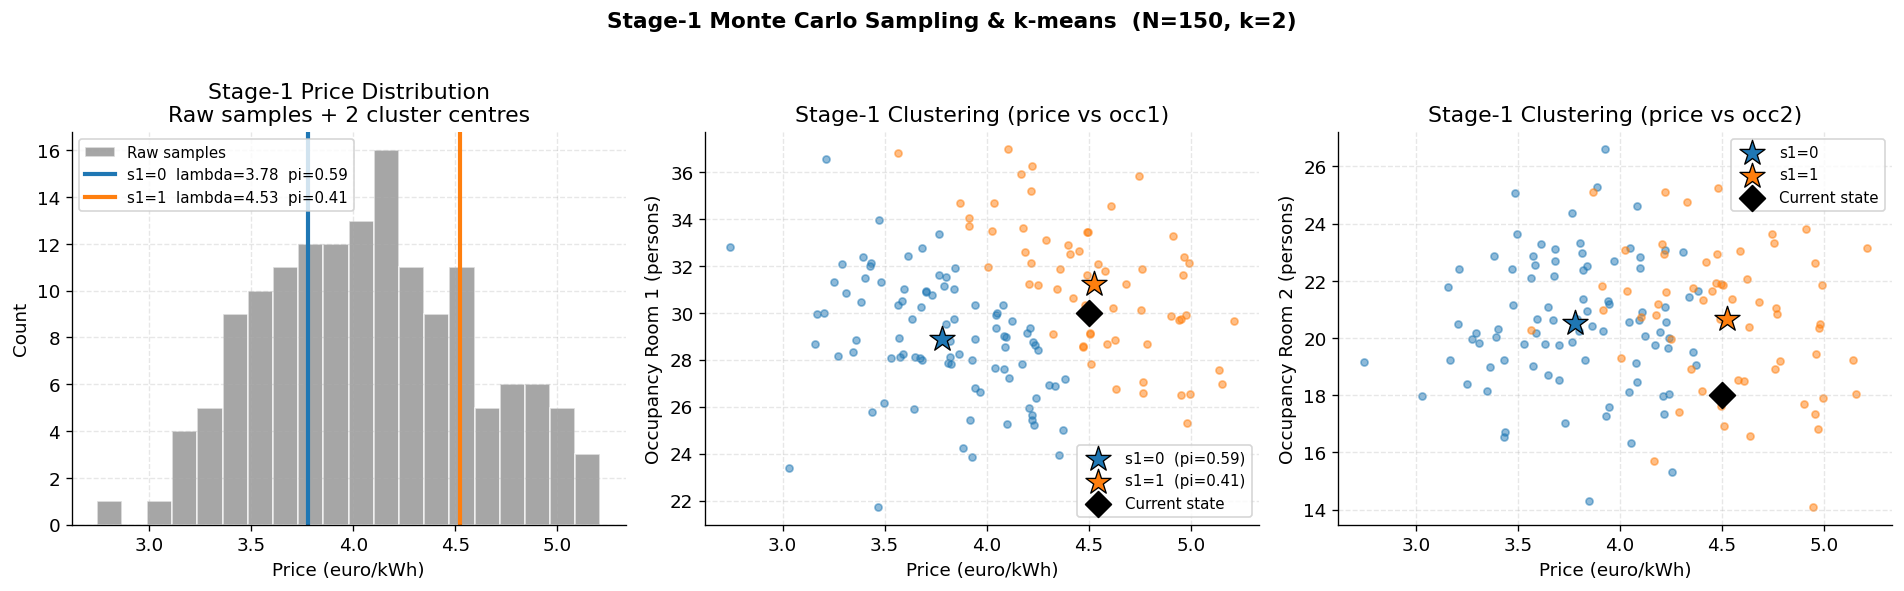


Stage-1 cluster centres (B=2):
  Branch     Price      Occ1      Occ2      Prob
  s1=0        3.779     28.88     20.54     0.593
  s1=1        4.525     31.24     20.68     0.407


In [53]:
# -- Fixed reference state for all illustrations -------------------------
np.random.seed(0)
DEMO_STATE = {
    "T1": 20.5, "T2": 19.8, "H": 48.0,
    "occ1": 30.0, "occ2": 18.0,
    "price": 4.5, "price_previous": 5.2,
    "c": 0, "y_low_1": 0, "y_low_2": 0,
    "y_high_1": 0, "y_high_2": 0, "current_time": 3,
}

# Re-expose internal helpers from the loaded SP module
_sample_price = _mod._sample_price
_sample_occ   = _mod._sample_occ
_cluster      = _mod._cluster

# Build demo scenario tree (uses notebook HORIZON / BRANCHES / N_INIT)
np.random.seed(0)
nodes_demo    = _mod.build_scenario_tree(DEMO_STATE, HORIZON, BRANCHES, N_INIT)
node_map_demo = {n["id"]: n for n in nodes_demo}
stage1_nodes  = [n for n in nodes_demo if n["stage"] == 1]

p0, pp0    = DEMO_STATE["price"], DEMO_STATE["price_previous"]
o1_0, o2_0 = DEMO_STATE["occ1"],  DEMO_STATE["occ2"]

# Stage-1 raw samples
np.random.seed(0)
p1_raw           = _sample_price(p0, pp0, N_INIT)
o1_raw, o2_raw   = _sample_occ(o1_0, o2_0, N_INIT)
feat1            = np.column_stack([p1_raw, o1_raw, o2_raw])
s1_centers, s1_probs = _cluster(feat1, BRANCHES)

from scipy.cluster.vq import kmeans2
std1 = feat1.std(axis=0); std1[std1 == 0] = 1.
_, labels1 = kmeans2(feat1 / std1, s1_centers / std1, iter=1, minit="matrix")
CMAP = plt.cm.tab10.colors

# -- Plot ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
ax.hist(p1_raw, bins=20, color="gray", edgecolor="white", alpha=0.7, label="Raw samples")
for k in range(BRANCHES):
    ax.axvline(s1_centers[k, 0], color=CMAP[k % 10], lw=2.5,
               label=fr"s1={k}  lambda={s1_centers[k,0]:.2f}  pi={s1_probs[k]:.2f}")
ax.set_xlabel("Price (euro/kWh)"); ax.set_ylabel("Count")
ax.set_title(f"Stage-1 Price Distribution\nRaw samples + {BRANCHES} cluster centres")
ax.legend(fontsize=9)

ax = axes[1]
for k in range(BRANCHES):
    mask = labels1 == k
    ax.scatter(feat1[mask, 0], feat1[mask, 1], color=CMAP[k % 10], s=18, alpha=0.5)
    ax.scatter(s1_centers[k, 0], s1_centers[k, 1],
               color=CMAP[k % 10], s=250, marker="*", edgecolors="black", lw=0.8, zorder=5,
               label=f"s1={k}  (pi={s1_probs[k]:.2f})")
ax.scatter(p0, o1_0, color="black", s=120, marker="D", zorder=6, label="Current state")
ax.set_xlabel("Price (euro/kWh)"); ax.set_ylabel("Occupancy Room 1 (persons)")
ax.set_title("Stage-1 Clustering (price vs occ1)")
ax.legend(fontsize=9)

ax = axes[2]
for k in range(BRANCHES):
    mask = labels1 == k
    ax.scatter(feat1[mask, 0], feat1[mask, 2], color=CMAP[k % 10], s=18, alpha=0.5)
    ax.scatter(s1_centers[k, 0], s1_centers[k, 2],
               color=CMAP[k % 10], s=250, marker="*", edgecolors="black", lw=0.8, zorder=5,
               label=f"s1={k}")
ax.scatter(p0, o2_0, color="black", s=120, marker="D", zorder=6, label="Current state")
ax.set_xlabel("Price (euro/kWh)"); ax.set_ylabel("Occupancy Room 2 (persons)")
ax.set_title("Stage-1 Clustering (price vs occ2)")
ax.legend(fontsize=9)

plt.suptitle(f"Stage-1 Monte Carlo Sampling & k-means  (N={N_INIT}, k={BRANCHES})",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"\nStage-1 cluster centres (B={BRANCHES}):")
print(f"{'Branch':>8}  {'Price':>8}  {'Occ1':>8}  {'Occ2':>8}  {'Prob':>8}")
for k in range(BRANCHES):
    print(f"  s1={k}     {s1_centers[k,0]:8.3f}  {s1_centers[k,1]:8.2f}  {s1_centers[k,2]:8.2f}  {s1_probs[k]:8.3f}")

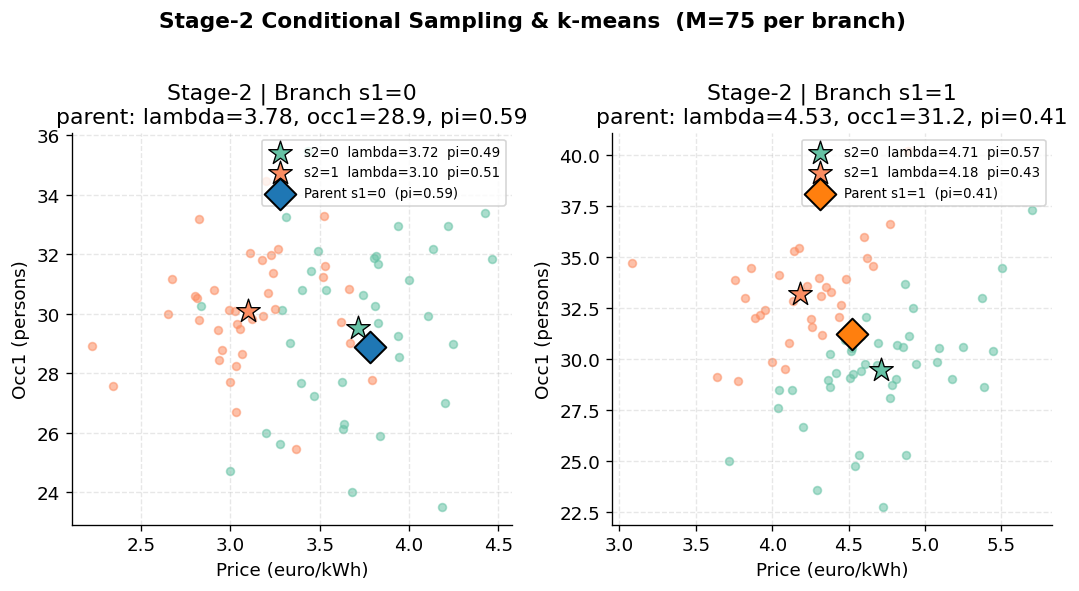

In [54]:
# Stage-2 conditional clustering: one panel per stage-1 branch
np.random.seed(1)
M_COND  = max(N_INIT // BRANCHES, 30)
CMAP2   = plt.cm.Set2.colors

n_cols = min(BRANCHES, 4)
n_rows = int(np.ceil(BRANCHES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4.5 * n_cols, 4.8 * n_rows),
                         squeeze=False)

s2_centers_all = {}
s2_probs_all   = {}

for k in range(BRANCHES):
    ax  = axes[k // n_cols][k % n_cols]
    nd1 = stage1_nodes[k]
    pc1, o1c1, o2c1 = nd1["price"], nd1["occ1"], nd1["occ2"]

    p2_raw      = _sample_price(pc1, p0, M_COND)
    o1_2, o2_2  = _sample_occ(o1c1, o2c1, M_COND)
    feat2       = np.column_stack([p2_raw, o1_2, o2_2])
    s2c, s2p    = _cluster(feat2, BRANCHES)
    s2_centers_all[k] = s2c
    s2_probs_all[k]   = s2p

    std2 = feat2.std(axis=0); std2[std2 == 0] = 1.
    _, labs2 = kmeans2(feat2 / std2, s2c / std2, iter=1, minit="matrix")

    for j in range(BRANCHES):
        mask = labs2 == j
        ax.scatter(feat2[mask, 0], feat2[mask, 1], color=CMAP2[j % 8], s=22, alpha=0.55)
        ax.scatter(s2c[j, 0], s2c[j, 1],
                   color=CMAP2[j % 8], s=220, marker="*", edgecolors="black", lw=0.8, zorder=5,
                   label=f"s2={j}  lambda={s2c[j,0]:.2f}  pi={s2p[j]:.2f}")
    ax.scatter(pc1, o1c1, color=CMAP[k % 10], s=180, marker="D",
               edgecolors="black", lw=1.2, zorder=6,
               label=f"Parent s1={k}  (pi={nd1['prob']:.2f})")
    ax.set_xlabel("Price (euro/kWh)"); ax.set_ylabel("Occ1 (persons)")
    ax.set_title(f"Stage-2 | Branch s1={k}\nparent: lambda={pc1:.2f}, occ1={o1c1:.1f}, pi={nd1['prob']:.2f}")
    ax.legend(fontsize=8, loc="upper right")

for idx in range(BRANCHES, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")

plt.suptitle(f"Stage-2 Conditional Sampling & k-means  (M={M_COND} per branch)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

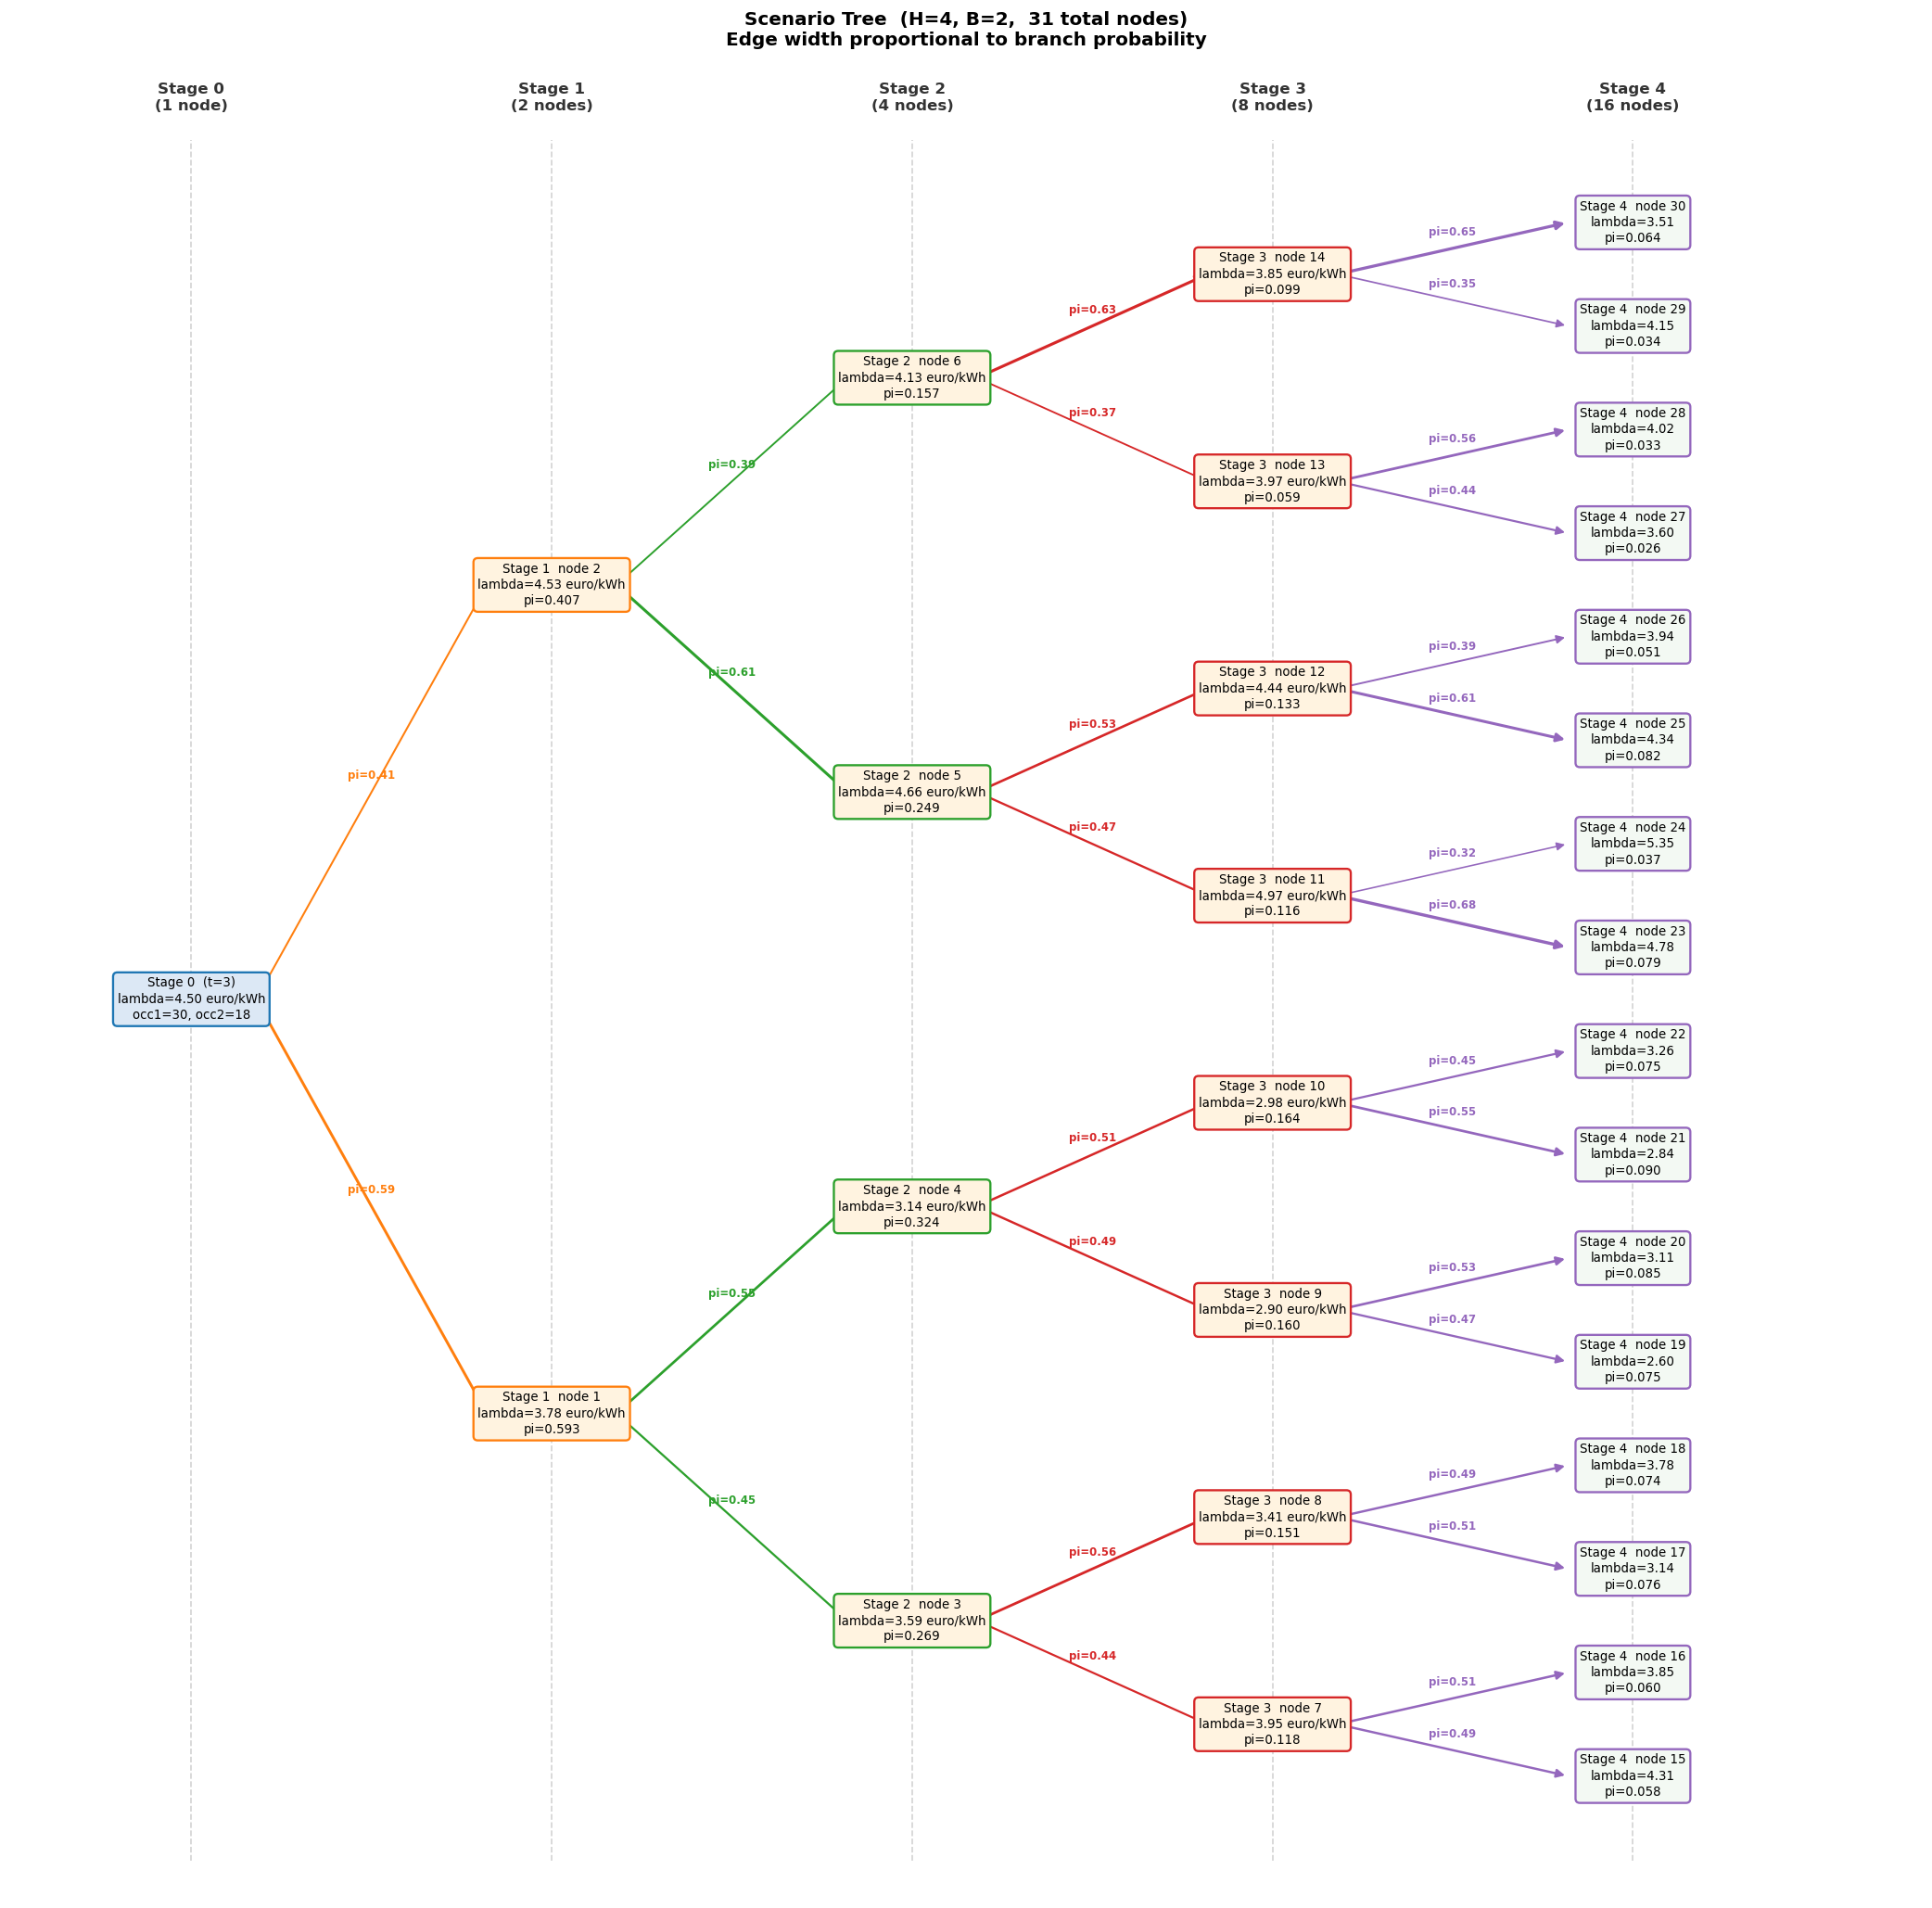

In [55]:
def draw_scenario_tree(demo_state, tree_nodes, horizon, branches):
    "Draw the scenario tree for any horizon H and branching factor B."
    n_leaves  = branches ** horizon
    node_map_ = {n['id']: n for n in tree_nodes}
    SCOLS     = plt.cm.tab10.colors

    # Y positions: leaves equally spaced, parents centred on children
    node_y = {}
    leaves = [n for n in tree_nodes if n['stage'] == horizon]
    total_h = max(10.0, n_leaves * 1.2)
    for i, ln in enumerate(leaves):
        node_y[ln['id']] = (i + 0.5) / n_leaves * total_h
    for stage in range(horizon - 1, -1, -1):
        for nd in [n for n in tree_nodes if n['stage'] == stage]:
            node_y[nd['id']] = np.mean([node_y[cid] for cid in nd['children']])

    fig_w = max(12, 3.5 * (horizon + 1))
    fig_h = max(6,  total_h * 0.9)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    ax.set_xlim(-0.5, horizon + 0.8)
    ax.set_ylim(-0.8, total_h + 1.2)
    x_pos = {s: s * (horizon / max(horizon, 1)) for s in range(horizon + 1)}

    def node_box(x, y, lines, fc, ec):
        ax.text(x, y, '\n'.join(lines), ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.35', fc=fc, ec=ec, lw=1.4),
                zorder=4, linespacing=1.3)

    for nd in tree_nodes:
        nid, stage = nd['id'], nd['stage']
        x, y = x_pos[stage], node_y[nid]
        col  = SCOLS[stage % 10]
        if stage == 0:
            fc    = '#dce8f5'
            lines = [f"Stage 0  (t={demo_state['current_time']})",
                     f"lambda={nd['price']:.2f} euro/kWh",
                     f"occ1={nd['occ1']:.0f}, occ2={nd['occ2']:.0f}"]
        elif stage < horizon:
            fc    = '#fff3e0'
            lines = [f"Stage {stage}  node {nid}",
                     f"lambda={nd['price']:.2f} euro/kWh",
                     f"pi={nd['prob']:.3f}"]
        else:
            fc    = '#f3f9f3'
            lines = [f"Stage {stage}  node {nid}",
                     f"lambda={nd['price']:.2f}",
                     f"pi={nd['prob']:.3f}"]
        node_box(x, y, lines, fc, col)
        if nd['parent_id'] is not None:
            par   = node_map_[nd['parent_id']]
            px, py = x_pos[stage - 1], node_y[nd['parent_id']]
            cond_p = nd['prob'] / par['prob'] if par['prob'] > 1e-9 else 0.0
            ax.annotate('', xy=(x - 0.18, y), xytext=(px + 0.18, py),
                        arrowprops=dict(arrowstyle='-|>', color=col, lw=max(0.8, 3*cond_p)))
            ax.text((px + x)/2, (py + y)/2 + 0.15, f"pi={cond_p:.2f}",
                    ha='center', fontsize=7, color=col, fontweight='bold')

    for stage in range(horizon + 1):
        n_at = branches ** stage
        ax.text(x_pos[stage], total_h + 0.7,
                f"Stage {stage}\n({n_at} node{'s' if n_at > 1 else ''})",
                ha='center', fontsize=10, fontweight='bold', color='#333')
        ax.axvline(x_pos[stage], color='lightgray', lw=1, ls='--', zorder=0,
                   ymin=0.02, ymax=0.96)

    total_nodes = len(tree_nodes)
    ax.set_title(f"Scenario Tree  (H={horizon}, B={branches},  {total_nodes} total nodes)\n"
                 "Edge width proportional to branch probability",
                 fontsize=12, fontweight='bold', pad=14)
    plt.tight_layout(); plt.show()

draw_scenario_tree(DEMO_STATE, nodes_demo, HORIZON, BRANCHES)

### MILP Solution Walkthrough

After the scenario tree is built, the MILP is solved and every node in the tree receives optimal decisions $(p_1, p_2, v)$. The cell below re-runs one full solve on the demo state, extracts **all 13 node solutions**, and visualises:

- The optimal action at every tree node (heating powers and ventilation)  
- The post-decision temperature and humidity at every node  
- The expected cost breakdown by stage  
- The 13 price trajectories realised in the scenario tree

In [56]:
import pyomo.environ as pyo

def solve_and_extract(state, seed=0):
    "Build tree + solve MILP. Returns (action, node_solutions, nodes)."
    np.random.seed(seed)
    nodes  = _mod.build_scenario_tree(state, HORIZON, BRANCHES, N_INIT)
    result = _mod.solve_multistage_sp(state, nodes)

    action = {
        'HeatPowerRoom1': result['HeatPowerRoom1'],
        'HeatPowerRoom2': result['HeatPowerRoom2'],
        'VentilationON':  result['VentilationON'],
    }

    m = result.get('_model')
    node_solutions = {}
    if m is not None:
        def val(x): return float(pyo.value(x))
        for nd in nodes:
            nid = nd['id']
            node_solutions[nid] = {
                'p1': val(m.p1[nid]), 'p2': val(m.p2[nid]),
                'v':  int(round(val(m.v[nid]))),
                'T1': val(m.T1[nid]), 'T2': val(m.T2[nid]), 'H': val(m.H[nid]),
                'price': nd['price'], 'prob': nd['prob'], 'stage': nd['stage'],
            }
    return action, node_solutions, nodes

print('Running MILP solve on demo state ...')
action0, node_solutions, tree_nodes = solve_and_extract(DEMO_STATE, seed=0)
print(f'\nHere-and-now action:  p1={action0["HeatPowerRoom1"]:.3f} kW  '
      f'p2={action0["HeatPowerRoom2"]:.3f} kW  v={action0["VentilationON"]}')
print(f'Tree: {len(tree_nodes)} nodes  (H={HORIZON}, B={BRANCHES})')

Running MILP solve on demo state ...



Here-and-now action:  p1=0.000 kW  p2=0.000 kW  v=0
Tree: 31 nodes  (H=4, B=2)


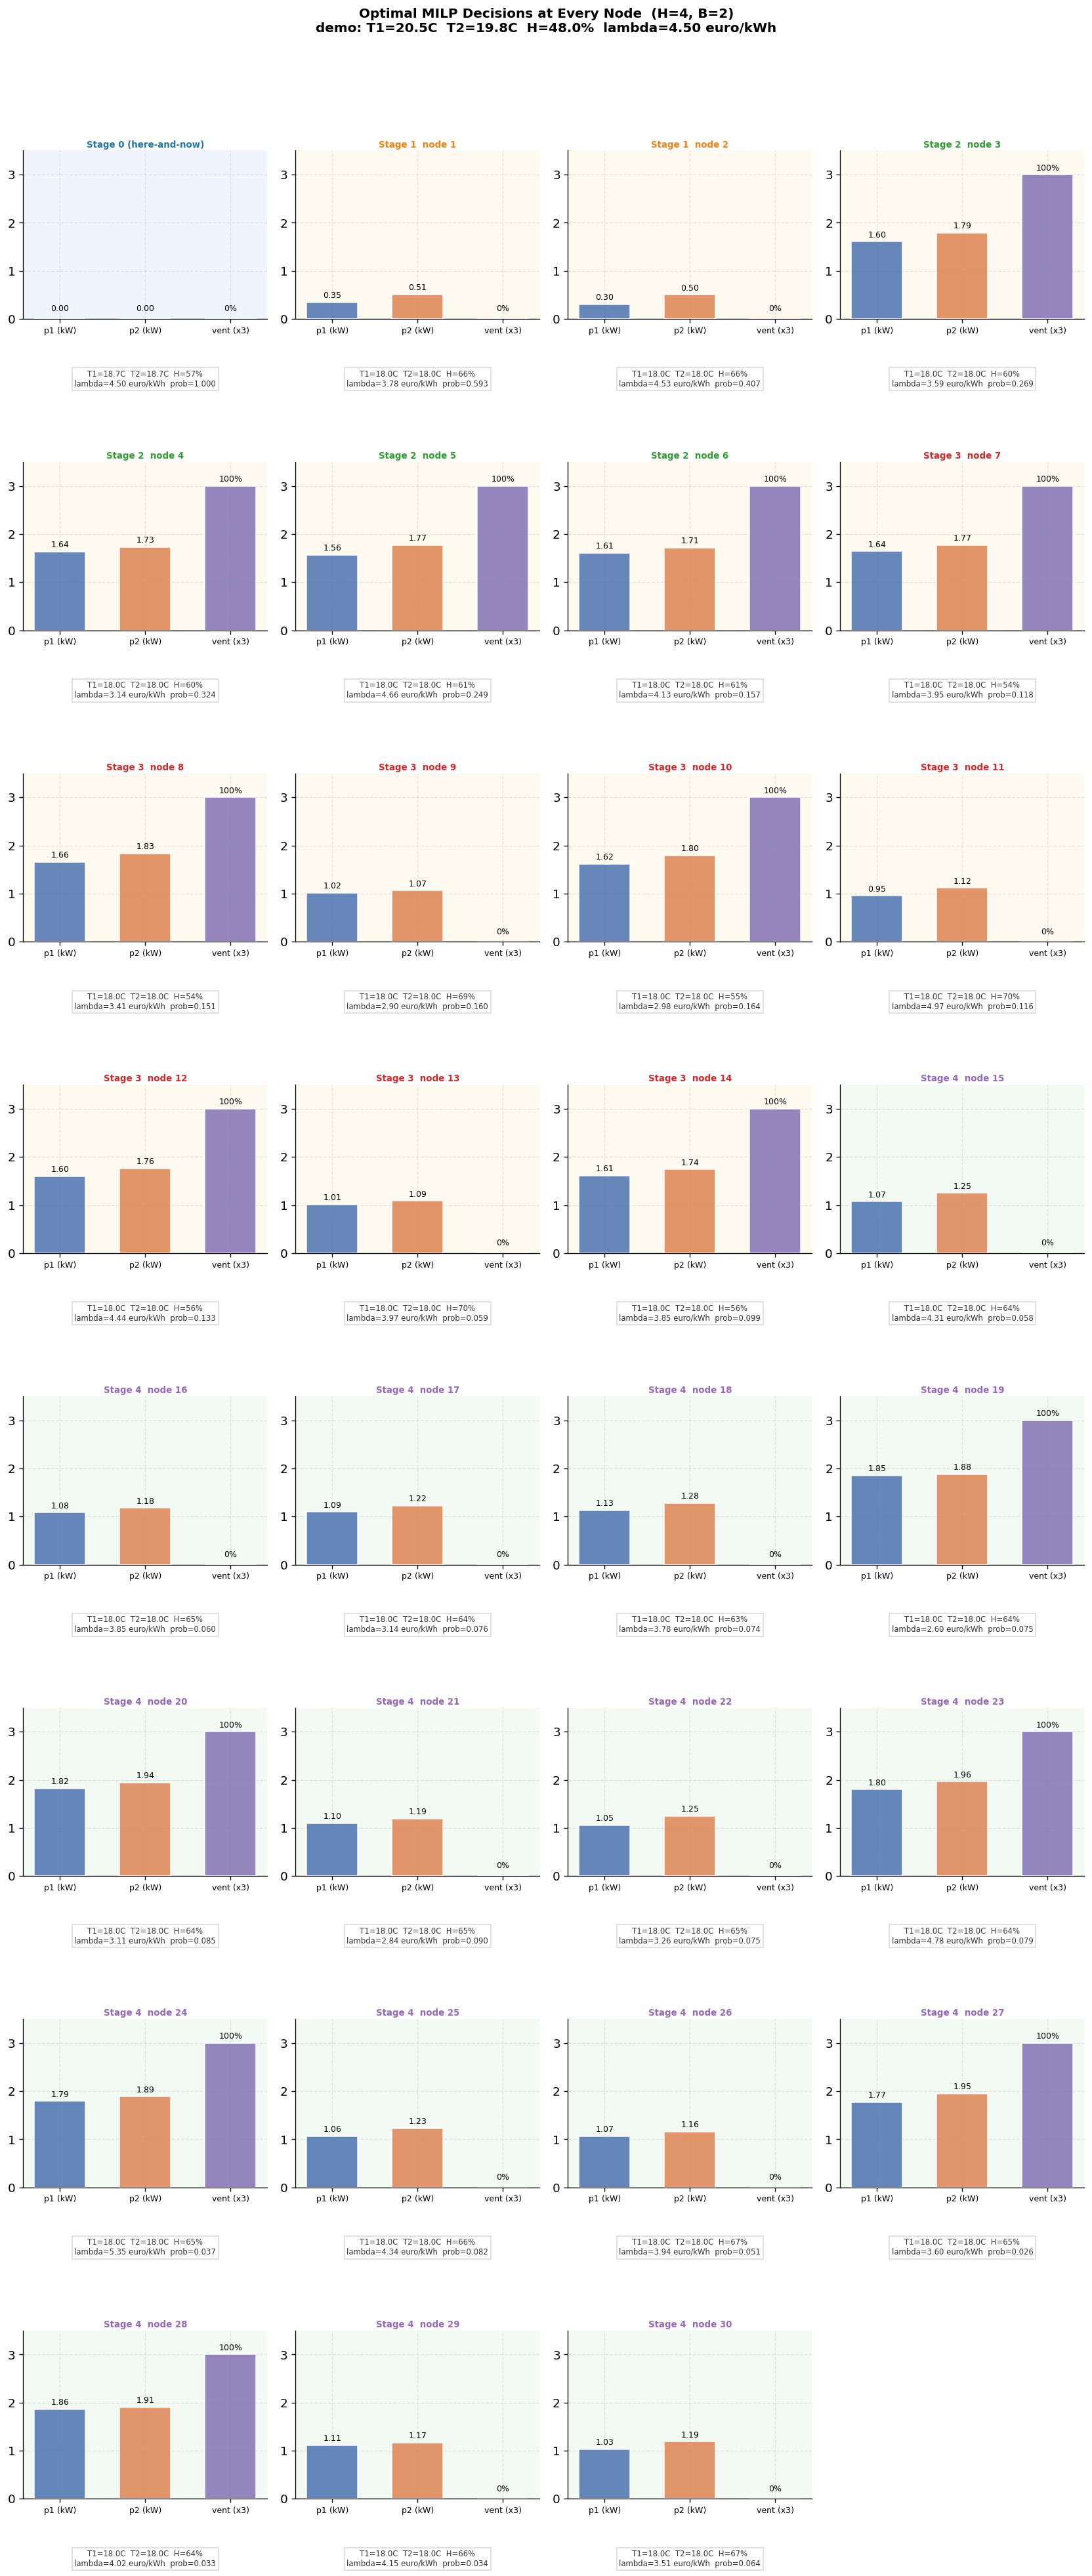

In [57]:
# Optimal MILP decisions at every scenario-tree node
if not node_solutions:
    print('No model solutions available (solver may have fallen back).')
else:
    n_nodes = len(tree_nodes)
    n_cols  = min(n_nodes, max(BRANCHES + 1, 4))
    n_rows  = int(np.ceil(n_nodes / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.5 * n_cols, 4.2 * n_rows),
                             squeeze=False)
    fig.suptitle(
        f'Optimal MILP Decisions at Every Node  (H={HORIZON}, B={BRANCHES})\n'
        f'demo: T1={DEMO_STATE["T1"]}C  T2={DEMO_STATE["T2"]}C  '
        f'H={DEMO_STATE["H"]}%  lambda={DEMO_STATE["price"]:.2f} euro/kWh',
        fontsize=12, fontweight='bold')

    x_grp  = np.array([0, 1, 2])
    xlbls  = ['p1 (kW)', 'p2 (kW)', 'vent (x3)']
    SCOLS  = plt.cm.tab10.colors

    def draw_panel(ax, sol, title, stage):
        vals = [sol['p1'], sol['p2'], sol['v'] * 3.0]
        cols = ['#4C72B0', '#DD8452', '#8172B3']
        bars = ax.bar(x_grp, vals, color=cols, alpha=0.85, edgecolor='white', width=0.6, zorder=3)
        for bar, v_ in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, max(bar.get_height()+0.05, 0.12),
                    f'{v_/3:.0%}' if bar is bars[2] else f'{v_:.2f}',
                    ha='center', va='bottom', fontsize=7.5)
        ax.set_ylim(0, 3.5); ax.set_xticks(x_grp); ax.set_xticklabels(xlbls, fontsize=7.5)
        ax.set_yticks([0, 1, 2, 3])
        ax.set_title(title, fontsize=8, fontweight='bold', pad=3, color=SCOLS[stage % 10])
        fc = '#f0f4ff' if stage == 0 else '#fffaf0' if stage < HORIZON else '#f3faf3'
        ax.set_facecolor(fc)
        ax.text(0.5, -0.4,
                f"T1={sol['T1']:.1f}C  T2={sol['T2']:.1f}C  H={sol['H']:.0f}%\n"
                f"lambda={sol['price']:.2f} euro/kWh  prob={sol['prob']:.3f}",
                transform=ax.transAxes, ha='center', fontsize=7, color='#333',
                bbox=dict(fc='white', ec='lightgray', pad=2, alpha=0.8))

    sorted_nodes = sorted(tree_nodes, key=lambda n: (n['stage'], n['id']))
    for idx, nd in enumerate(sorted_nodes):
        row, col = divmod(idx, n_cols)
        sol = node_solutions.get(nd['id'])
        if sol:
            lbl = f'Stage {nd["stage"]}  node {nd["id"]}' if nd['stage'] > 0 else 'Stage 0 (here-and-now)'
            draw_panel(axes[row][col], sol, lbl, nd['stage'])
        else:
            axes[row][col].axis('off')
    for idx in range(n_nodes, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.subplots_adjust(hspace=0.85)
    plt.show()

## 3. Simulation Environment

Implements the exact system dynamics from `v2_SystemCharacteristics.py`, the price AR(1) model from `PriceProcessRestaurant.py`, and the occupancy Markov process from `OccupancyProcessRestaurant.py`.

In [58]:
# -- System parameters (v2_SystemCharacteristics.py) ---------------------------
SYS = {
    "P_max"    : 3.0,   # max heating power per room (kW)
    "P_vent"   : 2.0,   # ventilation power (kW)
    "T_low"    : 18.0,  # low-temp comfort threshold (Â°C) -” triggers overrule
    "T_OK"     : 22.0,  # overrule deactivation threshold (Â°C)
    "T_high"   : 26.0,  # high-temp comfort threshold (Â°C) -” triggers overrule
    "H_high"   : 70.0,  # humidity threshold (%) -” forces ventilation ON
    "zeta_exch": 0.6,   # inter-room heat exchange coefficient
    "zeta_loss": 0.1,   # indoor-outdoor thermal loss coefficient
    "zeta_conv": 1.0,   # heating efficiency (Â°C / kW / h)
    "zeta_cool": 0.7,   # ventilation cooling (Â°C / h)
    "zeta_occ" : 0.02,  # occupancy heat gain (Â°C / person / h)
    "eta_occ"  : 0.18,  # occupancy humidity gain (% / person / h)
    "eta_vent" : 15.0,  # ventilation humidity removal (% / h)
}

# Deterministic outdoor temperature (sinusoidal)
def T_out(t: int) -> float:
    return 3.0 * np.sin(2.0 * np.pi * min(t, 9) / 10.0 - np.pi / 2.0)

# Price AR(1) process (PriceProcessRestaurant.py)
def price_step(current: float, previous: float) -> float:
    mean_p, rev = 4.0, 0.12
    next_p = current + 0.6 * (current - previous) + rev * (mean_p - current) + np.random.normal(0, 0.5)
    if next_p < 0 and np.random.rand() > 0.2:
        next_p = np.random.uniform(0, mean_p * 0.3)
    return float(np.clip(next_p, 0.0, 12.0))

# Occupancy Markov process (OccupancyProcessRestaurant.py)
def occ_step(r1: float, r2: float):
    r1n = r1 + 0.25 * (35 - r1) + 0.1 * (r2 - r1) + np.random.normal(0, 3.0)
    r2n = r2 + 0.25 * (25 - r2) + 0.1 * (r1 - r2) + np.random.normal(0, 2.5)
    return float(np.clip(r1n, 20, 50)), float(np.clip(r2n, 10, 30))

print("Environment helpers defined.")

Environment helpers defined.


In [59]:
def simulate_policy(pol, n_days: int = 50, seed: int = 42) -> dict:
    """
    Run `pol.select_action` for n_days Ã— 10 hours.

    Returns a dict with arrays of shape (n_days, 10) for all recorded quantities
    plus per-day totals and per-solve execution times.
    """
    np.random.seed(seed)
    p = SYS

    # Storage
    T1_log      = np.zeros((n_days, 10))
    T2_log      = np.zeros((n_days, 10))
    H_log       = np.zeros((n_days, 10))
    p1_log      = np.zeros((n_days, 10))
    p2_log      = np.zeros((n_days, 10))
    v_log       = np.zeros((n_days, 10))
    price_log   = np.zeros((n_days, 10))
    occ1_log    = np.zeros((n_days, 10))
    occ2_log    = np.zeros((n_days, 10))
    Tout_log    = np.array([T_out(t) for t in range(10)])
    cost_log    = np.zeros((n_days, 10))
    daily_costs = np.zeros(n_days)
    solve_times = []
    overrule    = {"lo1": 0, "lo2": 0, "hi1": 0, "hi2": 0, "hum": 0}

    for day in range(n_days):
        # -- Initial state ------------------------------------------------------
        state = {
            "T1": 21.0, "T2": 21.0, "H": 40.0,
            "occ1": float(np.random.uniform(25, 35)),
            "occ2": float(np.random.uniform(15, 25)),
            "price": float(np.random.uniform(2, 8)),
            "price_previous": float(np.random.uniform(2, 8)),
            "c": 0,
            "y_low_1": 0, "y_low_2": 0,
            "y_high_1": 0, "y_high_2": 0,
            "current_time": 0,
        }

        for t in range(10):
            state["current_time"] = t

            # -- Policy call ----------------------------------------------------
            t0 = time.perf_counter()
            try:
                action = pol.select_action(state)
            except Exception:
                action = {"HeatPowerRoom1": 0.0, "HeatPowerRoom2": 0.0, "VentilationON": 0}
            solve_times.append(time.perf_counter() - t0)

            # -- Parse & clip action --------------------------------------------
            p1 = float(np.clip(action.get("HeatPowerRoom1", 0), 0, p["P_max"]))
            p2 = float(np.clip(action.get("HeatPowerRoom2", 0), 0, p["P_max"]))
            v  = int(float(action.get("VentilationON", 0)) > 0.5)

            # -- Overrule controllers (simulation enforces constraints) ---------
            if state["y_low_1"]:           p1 = p["P_max"]
            if state["y_low_2"]:           p2 = p["P_max"]
            if state["y_high_1"]:          p1 = 0.0
            if state["y_high_2"]:          p2 = 0.0
            if state["c"] > 0:             v  = 1
            if state["H"] >= p["H_high"]:  v  = 1

            # Count overrule activations
            if state["y_low_1"]:           overrule["lo1"] += 1
            if state["y_low_2"]:           overrule["lo2"] += 1
            if state["y_high_1"]:          overrule["hi1"] += 1
            if state["y_high_2"]:          overrule["hi2"] += 1
            if state["H"] >= p["H_high"]:  overrule["hum"] += 1

            # -- Record ---------------------------------------------------------
            T1_log[day, t]    = state["T1"]
            T2_log[day, t]    = state["T2"]
            H_log[day, t]     = state["H"]
            p1_log[day, t]    = p1
            p2_log[day, t]    = p2
            v_log[day, t]     = v
            price_log[day, t] = state["price"]
            occ1_log[day, t]  = state["occ1"]
            occ2_log[day, t]  = state["occ2"]
            hourly_cost        = state["price"] * (p1 + p2 + p["P_vent"] * v)
            cost_log[day, t]  = hourly_cost
            daily_costs[day] += hourly_cost

            # -- State transition -----------------------------------------------
            To = T_out(t)
            T1n = (state["T1"]
                   + p["zeta_exch"] * (state["T2"] - state["T1"])
                   + p["zeta_loss"] * (To          - state["T1"])
                   + p["zeta_conv"] * p1
                   - p["zeta_cool"] * v
                   + p["zeta_occ"]  * state["occ1"])
            T2n = (state["T2"]
                   + p["zeta_exch"] * (state["T1"] - state["T2"])
                   + p["zeta_loss"] * (To          - state["T2"])
                   + p["zeta_conv"] * p2
                   - p["zeta_cool"] * v
                   + p["zeta_occ"]  * state["occ2"])
            Hn  = max(0.0, state["H"]
                      + p["eta_occ"]  * (state["occ1"] + state["occ2"])
                      - p["eta_vent"] * v)

            o1n, o2n = occ_step(state["occ1"], state["occ2"])
            pn       = price_step(state["price"], state["price_previous"])

            # Ventilation inertia counter
            if v == 1 and state["c"] == 0:
                cn = 2       # new ON-cycle: 2 more forced hours
            elif v == 1:
                cn = max(0, state["c"] - 1)
            else:
                cn = 0

            # Low-temperature overrule (hysteresis)
            y_lo1 = (1 if T1n < p["T_low"] else
                     0 if T1n >= p["T_OK"] else state["y_low_1"])
            y_lo2 = (1 if T2n < p["T_low"] else
                     0 if T2n >= p["T_OK"] else state["y_low_2"])
            # High-temperature overrule (no hysteresis)
            y_hi1 = 1 if T1n > p["T_high"] else 0
            y_hi2 = 1 if T2n > p["T_high"] else 0

            state = {
                "T1": T1n, "T2": T2n, "H": Hn,
                "occ1": o1n, "occ2": o2n,
                "price": pn, "price_previous": state["price"],
                "c": cn,
                "y_low_1": y_lo1, "y_low_2": y_lo2,
                "y_high_1": y_hi1, "y_high_2": y_hi2,
                "current_time": t,
            }

        if (day + 1) % 10 == 0 or day == 0:
            print(f"  Day {day+1:>3}/{n_days}  |  daily cost = {daily_costs[day]:6.2f} â‚¬"
                  f"  |  avg solve = {np.mean(solve_times[-10:]):.3f}s")

    total_time = sum(solve_times)
    print(f"\nDone. {n_days} days Ã— 10 hours = {n_days*10} MILP solves"
          f"  |  total = {total_time:.1f}s  |  avg = {np.mean(solve_times)*1000:.1f}ms")
    return {
        "daily_costs" : daily_costs,
        "cost_log"    : cost_log,
        "T1"          : T1_log,
        "T2"          : T2_log,
        "H"           : H_log,
        "p1"          : p1_log,
        "p2"          : p2_log,
        "v"           : v_log,
        "prices"      : price_log,
        "occ1"        : occ1_log,
        "occ2"        : occ2_log,
        "T_out"       : Tout_log,
        "solve_times" : np.array(solve_times),
        "overrule"    : overrule,
        "n_days"      : n_days,
    }

print("Simulation function defined.")

Simulation function defined.


## 4. Run Simulation

In [60]:
print(f"Running SP policy for {N_DAYS} days -¦\n")
R = simulate_policy(policy, n_days=N_DAYS, seed=SEED)

Running SP policy for 50 days -¦

  Day   1/50  |  daily cost = 191.95 â‚¬  |  avg solve = 0.070s
  Day  10/50  |  daily cost =  93.03 â‚¬  |  avg solve = 0.071s
  Day  20/50  |  daily cost = 187.40 â‚¬  |  avg solve = 0.083s
  Day  30/50  |  daily cost = 294.35 â‚¬  |  avg solve = 0.077s
  Day  40/50  |  daily cost = 194.32 â‚¬  |  avg solve = 0.084s
  Day  50/50  |  daily cost =  63.02 â‚¬  |  avg solve = 0.118s

Done. 50 days Ã— 10 hours = 500 MILP solves  |  total = 50.1s  |  avg = 100.1ms


## 5. Results

### 5.1 Daily Cost Distribution

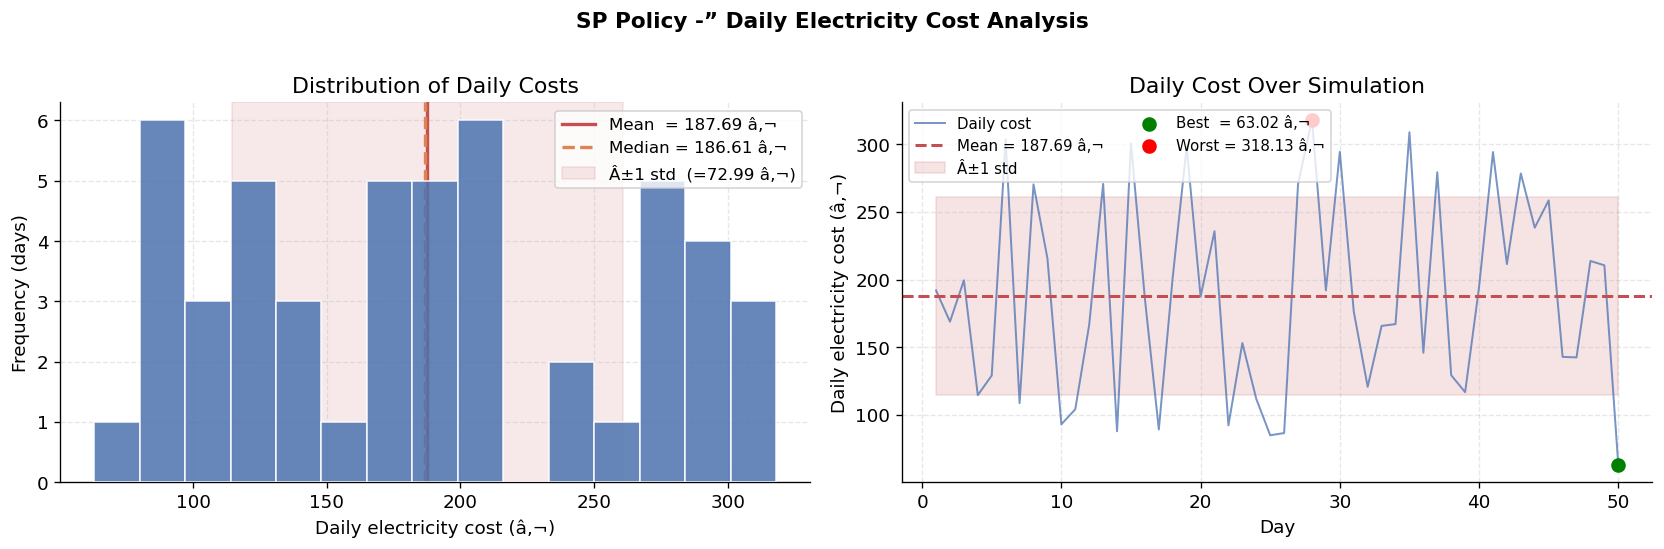

In [61]:
costs = R["daily_costs"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# -- Left: histogram ------------------------------------------------------------
ax = axes[0]
ax.hist(costs, bins=15, color="#4C72B0", edgecolor="white", alpha=0.85, zorder=3)
ax.axvline(costs.mean(),   color="#C44E52", lw=2.0, label=f"Mean  = {costs.mean():.2f} â‚¬")
ax.axvline(np.median(costs), color="#DD8452", lw=2.0, ls="--", label=f"Median = {np.median(costs):.2f} â‚¬")
ax.axvspan(costs.mean() - costs.std(), costs.mean() + costs.std(),
           alpha=0.12, color="#C44E52", label=f"Â±1 std  (={costs.std():.2f} â‚¬)")
ax.set_xlabel("Daily electricity cost (â‚¬)")
ax.set_ylabel("Frequency (days)")
ax.set_title("Distribution of Daily Costs")
ax.legend(fontsize=10)

# -- Right: cost timeline -------------------------------------------------------
ax = axes[1]
days = np.arange(1, R["n_days"] + 1)
ax.plot(days, costs, color="#4C72B0", lw=1.2, alpha=0.75, label="Daily cost")
ax.axhline(costs.mean(), color="#C44E52", lw=1.8, ls="--",
           label=f"Mean = {costs.mean():.2f} â‚¬")
ax.fill_between(days,
                costs.mean() - costs.std(), costs.mean() + costs.std(),
                alpha=0.15, color="#C44E52", label="Â±1 std")
# Mark best and worst days
ax.scatter(days[np.argmin(costs)], costs.min(), color="green", zorder=5, s=60,
           label=f"Best  = {costs.min():.2f} â‚¬")
ax.scatter(days[np.argmax(costs)], costs.max(), color="red",   zorder=5, s=60,
           label=f"Worst = {costs.max():.2f} â‚¬")
ax.set_xlabel("Day")
ax.set_ylabel("Daily electricity cost (â‚¬)")
ax.set_title("Daily Cost Over Simulation")
ax.legend(fontsize=9, ncol=2)

plt.suptitle("SP Policy -” Daily Electricity Cost Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Temperature Trajectories

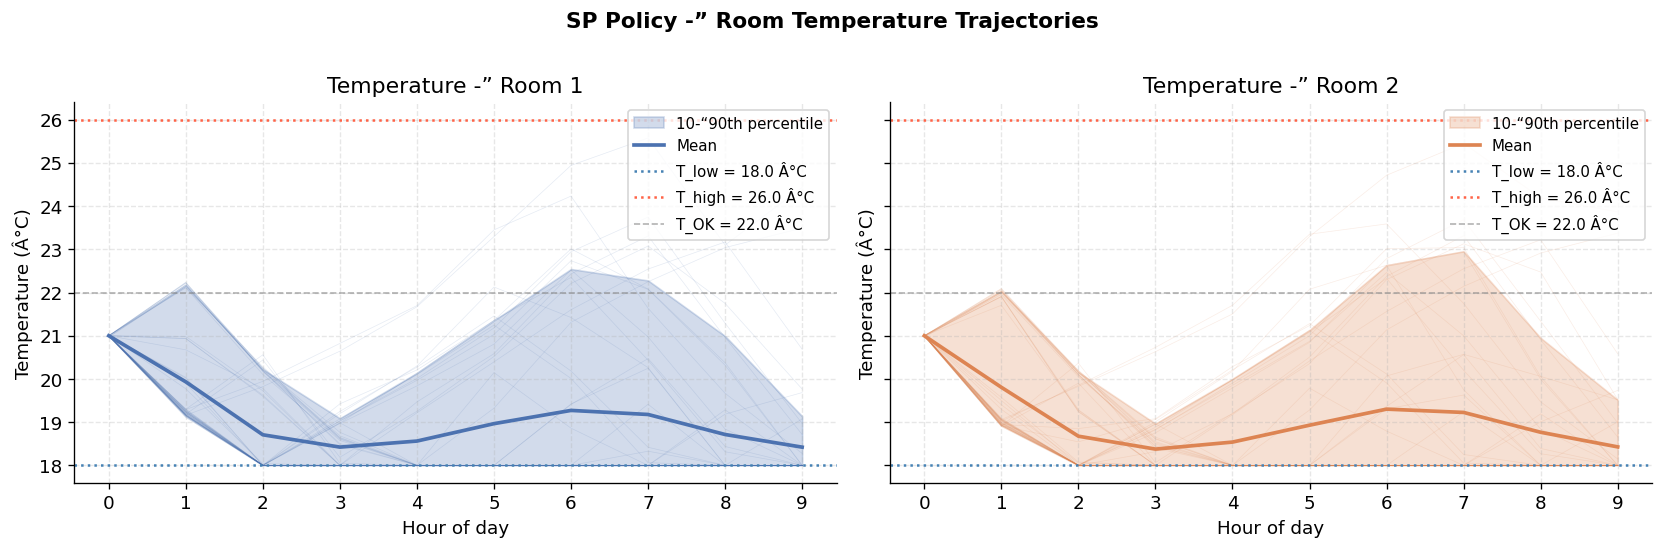

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
colors = {"r1": "#4C72B0", "r2": "#DD8452"}

for ax, key, label, col in [
        (axes[0], "T1", "Room 1", colors["r1"]),
        (axes[1], "T2", "Room 2", colors["r2"])]:

    T = R[key]                    # (n_days, 10)
    T_mean = T.mean(axis=0)
    T_p10  = np.percentile(T, 10, axis=0)
    T_p90  = np.percentile(T, 90, axis=0)

    # Individual day trajectories (light, thin)
    for d in range(R["n_days"]):
        ax.plot(HOURS, T[d], color=col, lw=0.4, alpha=0.15)

    # 10-90 percentile band
    ax.fill_between(HOURS, T_p10, T_p90, color=col, alpha=0.25,
                    label="10-“90th percentile")
    # Mean
    ax.plot(HOURS, T_mean, color=col, lw=2.2, label="Mean")

    # Comfort bounds
    ax.axhline(SYS["T_low"],  color="steelblue", lw=1.5, ls=":", label=f'T_low = {SYS["T_low"]} Â°C')
    ax.axhline(SYS["T_high"], color="tomato",    lw=1.5, ls=":", label=f'T_high = {SYS["T_high"]} Â°C')
    ax.axhline(SYS["T_OK"],   color="gray",      lw=1.0, ls="--", alpha=0.6, label=f'T_OK = {SYS["T_OK"]} Â°C')

    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Temperature (Â°C)")
    ax.set_title(f"Temperature -” {label}")
    ax.set_xticks(HOURS)
    ax.legend(fontsize=9, loc="upper right")

plt.suptitle("SP Policy -” Room Temperature Trajectories", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Humidity Trajectory

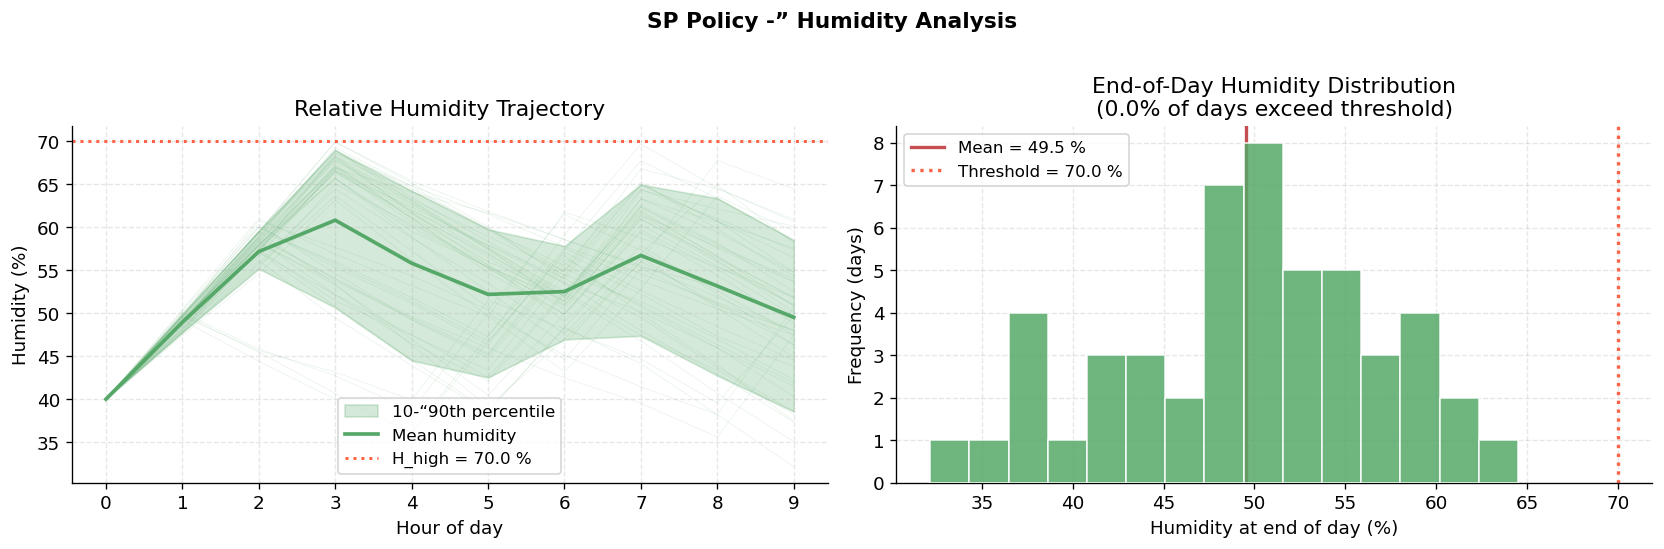

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# -- Left: humidity trajectory --------------------------------------------------
ax = axes[0]
H = R["H"]
H_mean = H.mean(axis=0)
H_p10  = np.percentile(H, 10, axis=0)
H_p90  = np.percentile(H, 90, axis=0)

for d in range(R["n_days"]):
    ax.plot(HOURS, H[d], color="#55A868", lw=0.4, alpha=0.15)
ax.fill_between(HOURS, H_p10, H_p90, color="#55A868", alpha=0.25, label="10-“90th percentile")
ax.plot(HOURS, H_mean, color="#55A868", lw=2.2, label="Mean humidity")
ax.axhline(SYS["H_high"], color="tomato", lw=1.8, ls=":", label=f'H_high = {SYS["H_high"]} %')

ax.set_xlabel("Hour of day")
ax.set_ylabel("Humidity (%)")
ax.set_title("Relative Humidity Trajectory")
ax.set_xticks(HOURS)
ax.legend(fontsize=10)

# -- Right: humidity end-of-day distribution -----------------------------------
ax = axes[1]
H_final = H[:, -1]   # humidity at end of day (hour 9)
ax.hist(H_final, bins=15, color="#55A868", edgecolor="white", alpha=0.85, zorder=3)
ax.axvline(H_final.mean(), color="#C44E52", lw=2, label=f"Mean = {H_final.mean():.1f} %")
ax.axvline(SYS["H_high"],  color="tomato",  lw=2, ls=":", label=f'Threshold = {SYS["H_high"]} %')
frac_above = (H_final > SYS["H_high"]).mean() * 100
ax.set_xlabel("Humidity at end of day (%)")
ax.set_ylabel("Frequency (days)")
ax.set_title(f"End-of-Day Humidity Distribution\n({frac_above:.1f}% of days exceed threshold)")
ax.legend(fontsize=10)

plt.suptitle("SP Policy -” Humidity Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Action Profiles -” Heating Powers & Ventilation

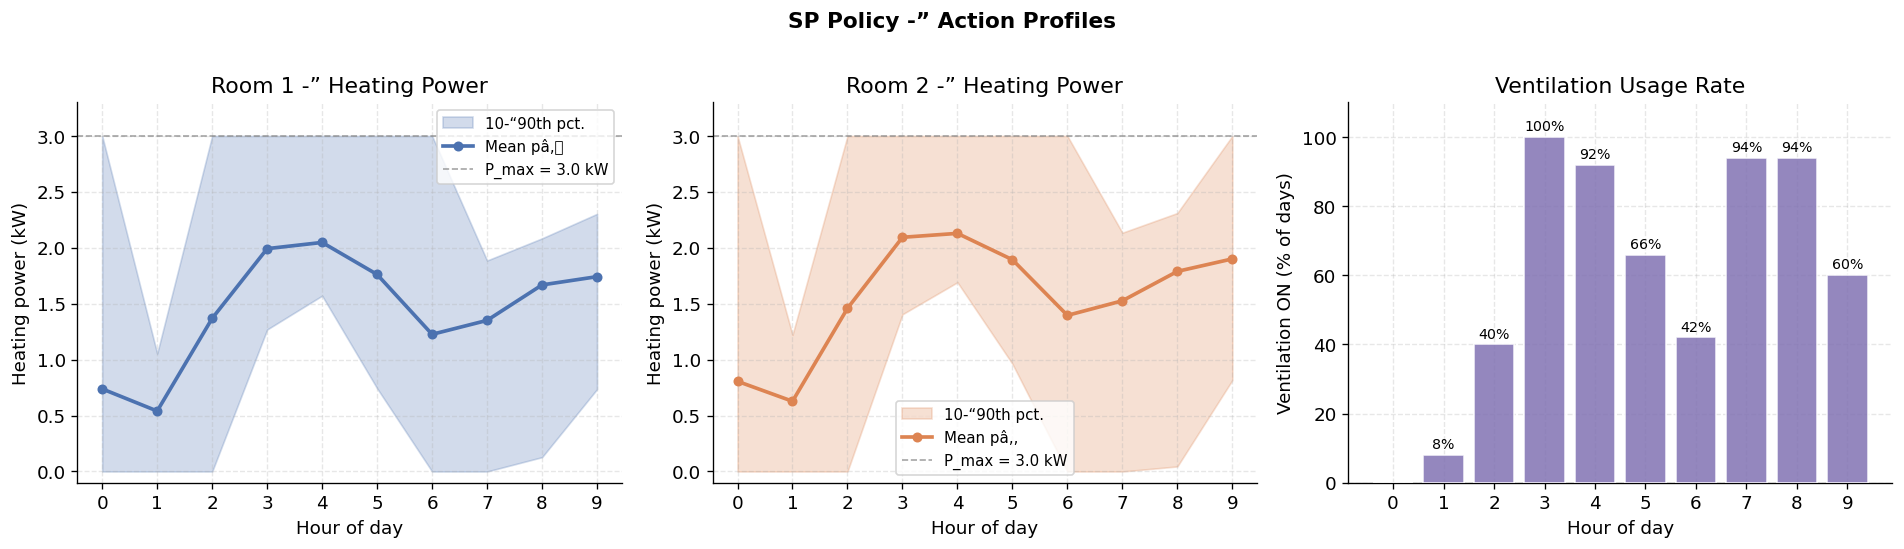

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# -- Heating power Room 1 -------------------------------------------------------
ax = axes[0]
p1_mean = R["p1"].mean(axis=0)
p1_p10  = np.percentile(R["p1"], 10, axis=0)
p1_p90  = np.percentile(R["p1"], 90, axis=0)
ax.fill_between(HOURS, p1_p10, p1_p90, color="#4C72B0", alpha=0.25, label="10-“90th pct.")
ax.plot(HOURS, p1_mean, color="#4C72B0", lw=2.2, marker="o", ms=5, label="Mean pâ‚")
ax.axhline(SYS["P_max"], color="gray", lw=1, ls="--", alpha=0.7, label=f'P_max = {SYS["P_max"]} kW')
ax.set_ylim(-0.1, SYS["P_max"] + 0.3)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Heating power (kW)")
ax.set_title("Room 1 -” Heating Power")
ax.set_xticks(HOURS); ax.legend(fontsize=9)

# -- Heating power Room 2 -------------------------------------------------------
ax = axes[1]
p2_mean = R["p2"].mean(axis=0)
p2_p10  = np.percentile(R["p2"], 10, axis=0)
p2_p90  = np.percentile(R["p2"], 90, axis=0)
ax.fill_between(HOURS, p2_p10, p2_p90, color="#DD8452", alpha=0.25, label="10-“90th pct.")
ax.plot(HOURS, p2_mean, color="#DD8452", lw=2.2, marker="o", ms=5, label="Mean pâ‚‚")
ax.axhline(SYS["P_max"], color="gray", lw=1, ls="--", alpha=0.7, label=f'P_max = {SYS["P_max"]} kW')
ax.set_ylim(-0.1, SYS["P_max"] + 0.3)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Heating power (kW)")
ax.set_title("Room 2 -” Heating Power")
ax.set_xticks(HOURS); ax.legend(fontsize=9)

# -- Ventilation usage rate per hour --------------------------------------------
ax = axes[2]
v_rate = R["v"].mean(axis=0) * 100   # % of days with vent ON at each hour
bars = ax.bar(HOURS, v_rate, color="#8172B3", alpha=0.85, edgecolor="white", zorder=3)
# Annotate bars
for bar, val in zip(bars, v_rate):
    if val > 2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=8.5)
ax.set_ylim(0, 110)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Ventilation ON (% of days)")
ax.set_title("Ventilation Usage Rate")
ax.set_xticks(HOURS)

plt.suptitle("SP Policy -” Action Profiles", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.5 Electricity Price Analysis

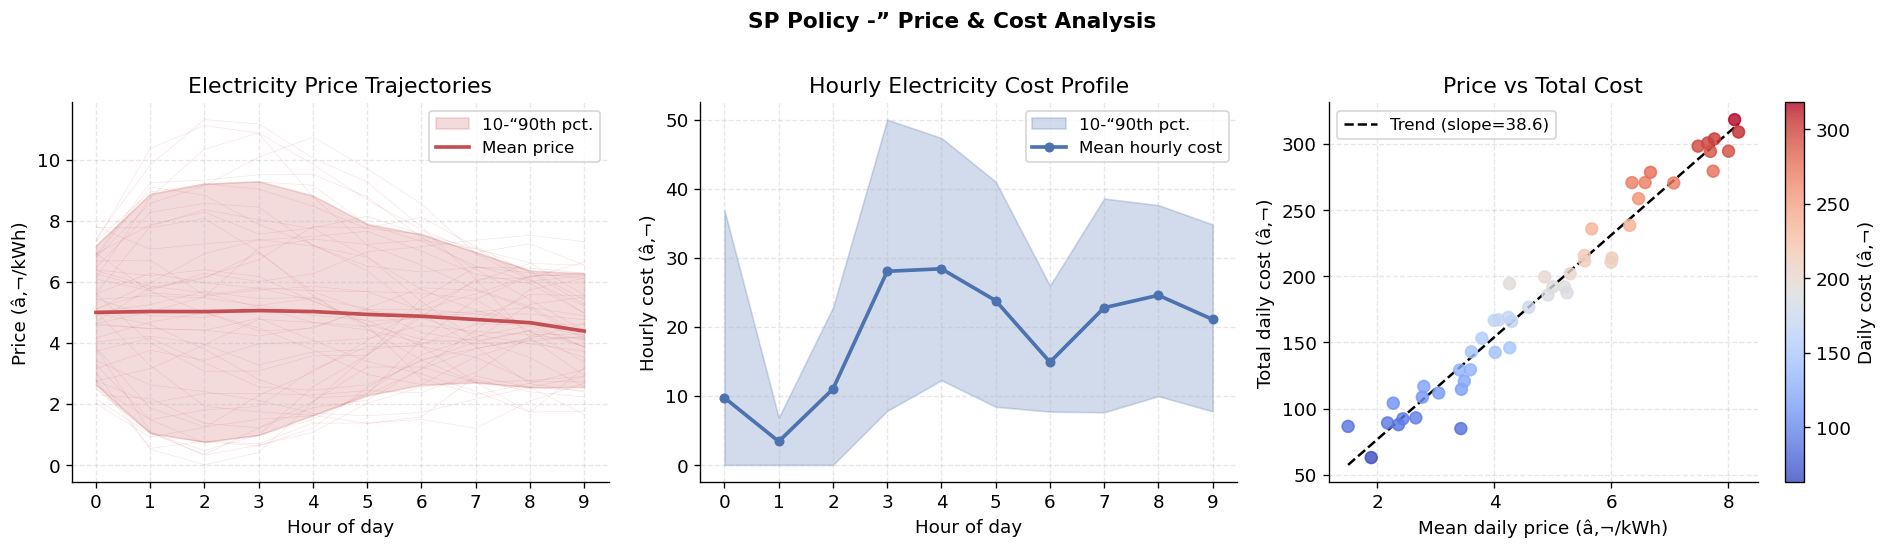

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# -- Price trajectory -----------------------------------------------------------
ax = axes[0]
pr = R["prices"]
pr_mean = pr.mean(axis=0)
pr_p10  = np.percentile(pr, 10, axis=0)
pr_p90  = np.percentile(pr, 90, axis=0)
for d in range(R["n_days"]):
    ax.plot(HOURS, pr[d], color="#C44E52", lw=0.4, alpha=0.15)
ax.fill_between(HOURS, pr_p10, pr_p90, color="#C44E52", alpha=0.2, label="10-“90th pct.")
ax.plot(HOURS, pr_mean, color="#C44E52", lw=2.2, label="Mean price")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Price (â‚¬/kWh)")
ax.set_title("Electricity Price Trajectories")
ax.set_xticks(HOURS); ax.legend(fontsize=10)

# -- Hourly cost profile --------------------------------------------------------
ax = axes[1]
hc_mean = R["cost_log"].mean(axis=0)
hc_p10  = np.percentile(R["cost_log"], 10, axis=0)
hc_p90  = np.percentile(R["cost_log"], 90, axis=0)
ax.fill_between(HOURS, hc_p10, hc_p90, color="#4C72B0", alpha=0.25, label="10-“90th pct.")
ax.plot(HOURS, hc_mean, color="#4C72B0", lw=2.2, marker="o", ms=5, label="Mean hourly cost")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Hourly cost (â‚¬)")
ax.set_title("Hourly Electricity Cost Profile")
ax.set_xticks(HOURS); ax.legend(fontsize=10)

# -- Scatter: mean daily price vs total daily cost -----------------------------
ax = axes[2]
mean_daily_price = R["prices"].mean(axis=1)
sc = ax.scatter(mean_daily_price, R["daily_costs"],
                c=R["daily_costs"], cmap="coolwarm", s=50, alpha=0.8, zorder=3)
plt.colorbar(sc, ax=ax, label="Daily cost (â‚¬)")
# Trend line
z = np.polyfit(mean_daily_price, R["daily_costs"], 1)
xr = np.linspace(mean_daily_price.min(), mean_daily_price.max(), 50)
ax.plot(xr, np.polyval(z, xr), "k--", lw=1.5, label=f"Trend (slope={z[0]:.1f})")
ax.set_xlabel("Mean daily price (â‚¬/kWh)")
ax.set_ylabel("Total daily cost (â‚¬)")
ax.set_title("Price vs Total Cost")
ax.legend(fontsize=10)

plt.suptitle("SP Policy -” Price & Cost Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.6 Overrule Controller Activations & Solver Performance

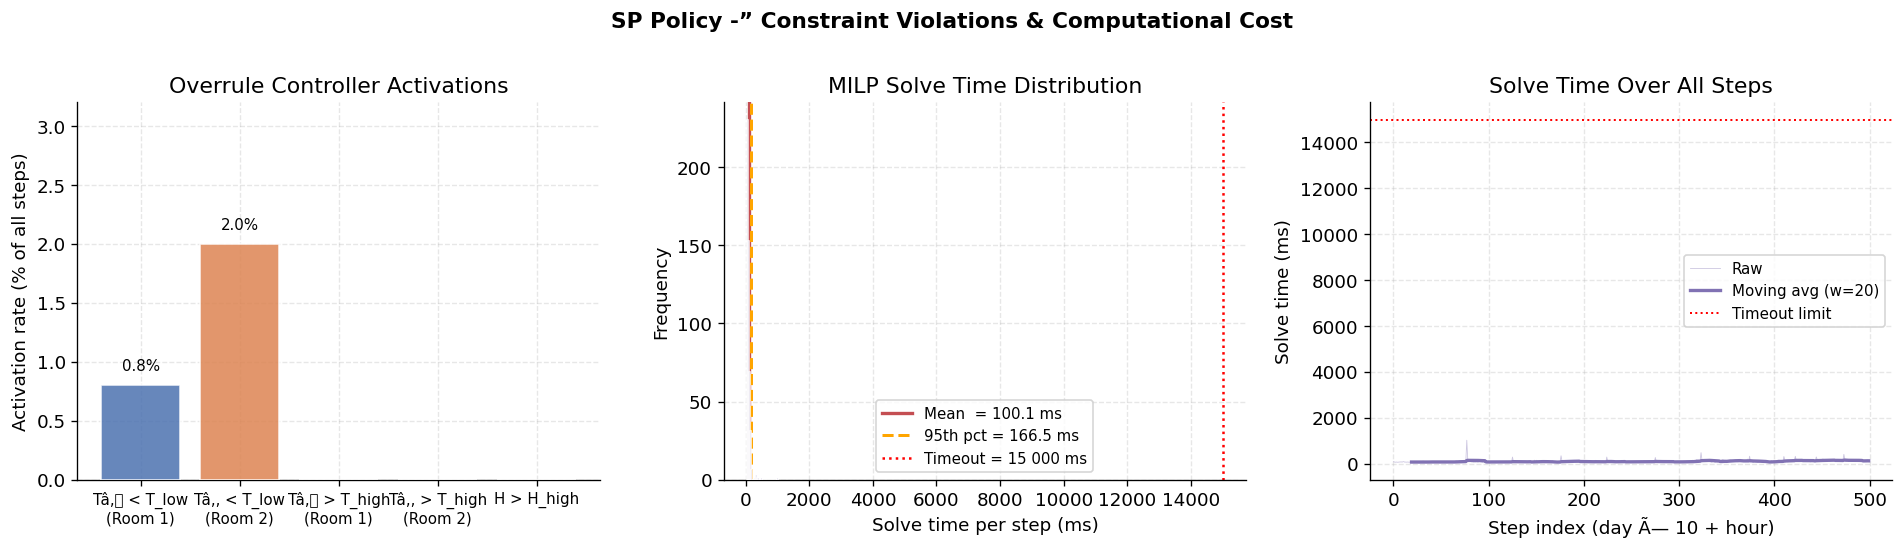

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# -- Overrule bar chart ---------------------------------------------------------
ax = axes[0]
ov  = R["overrule"]
total_steps = R["n_days"] * 10
labels = ["Tâ‚ < T_low\n(Room 1)", "Tâ‚‚ < T_low\n(Room 2)",
          "Tâ‚ > T_high\n(Room 1)", "Tâ‚‚ > T_high\n(Room 2)", "H > H_high"]
vals   = [ov["lo1"], ov["lo2"], ov["hi1"], ov["hi2"], ov["hum"]]
colors_ov = ["#4C72B0", "#DD8452", "#C44E52", "#E377C2", "#55A868"]
bars = ax.bar(labels, [v / total_steps * 100 for v in vals],
              color=colors_ov, edgecolor="white", alpha=0.85, zorder=3)
for bar, v in zip(bars, vals):
    pct = v / total_steps * 100
    if pct > 0.1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Activation rate (% of all steps)")
ax.set_title("Overrule Controller Activations")
ax.set_ylim(0, max([v/total_steps*100 for v in vals]) * 1.35 + 0.5)
ax.tick_params(axis="x", labelsize=9)

# -- Solve time distribution ----------------------------------------------------
ax = axes[1]
st = R["solve_times"] * 1000   # â†’ milliseconds
ax.hist(st, bins=30, color="#8172B3", edgecolor="white", alpha=0.85, zorder=3)
ax.axvline(st.mean(),   color="#C44E52", lw=2, label=f"Mean  = {st.mean():.1f} ms")
ax.axvline(np.percentile(st, 95), color="orange", lw=1.8, ls="--",
           label=f"95th pct = {np.percentile(st, 95):.1f} ms")
ax.axvline(15000, color="red", lw=1.5, ls=":", label="Timeout = 15 000 ms")
ax.set_xlabel("Solve time per step (ms)")
ax.set_ylabel("Frequency")
ax.set_title("MILP Solve Time Distribution")
ax.legend(fontsize=9)

# -- Solve time over episode (moving average) -----------------------------------
ax = axes[2]
window = 20
ma = np.convolve(st, np.ones(window)/window, mode="valid")
ax.plot(st, color="#8172B3", lw=0.5, alpha=0.4, label="Raw")
ax.plot(np.arange(window-1, len(st)), ma, color="#8172B3", lw=2.0,
        label=f"Moving avg (w={window})")
ax.axhline(15000, color="red", lw=1.2, ls=":", label="Timeout limit")
ax.set_xlabel("Step index (day Ã— 10 + hour)")
ax.set_ylabel("Solve time (ms)")
ax.set_title("Solve Time Over All Steps")
ax.legend(fontsize=9)

plt.suptitle("SP Policy -” Constraint Violations & Computational Cost",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.7 Occupancy & Exogenous Variables

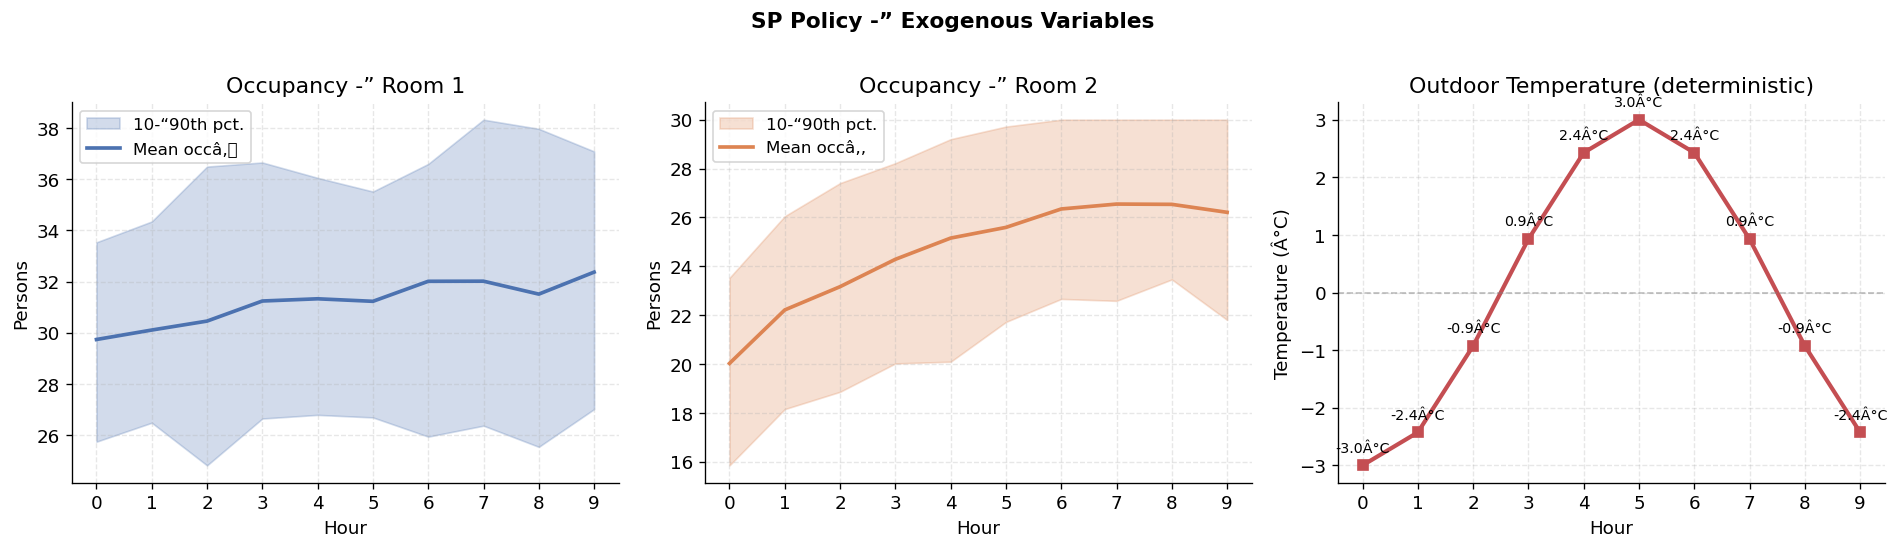

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# -- Occupancy Room 1 -----------------------------------------------------------
ax = axes[0]
o1 = R["occ1"]
ax.fill_between(HOURS, np.percentile(o1,10,axis=0), np.percentile(o1,90,axis=0),
                color="#4C72B0", alpha=0.25, label="10-“90th pct.")
ax.plot(HOURS, o1.mean(axis=0), color="#4C72B0", lw=2.2, label="Mean occâ‚")
ax.set_xlabel("Hour"); ax.set_ylabel("Persons"); ax.set_title("Occupancy -” Room 1")
ax.set_xticks(HOURS); ax.legend(fontsize=10)

# -- Occupancy Room 2 -----------------------------------------------------------
ax = axes[1]
o2 = R["occ2"]
ax.fill_between(HOURS, np.percentile(o2,10,axis=0), np.percentile(o2,90,axis=0),
                color="#DD8452", alpha=0.25, label="10-“90th pct.")
ax.plot(HOURS, o2.mean(axis=0), color="#DD8452", lw=2.2, label="Mean occâ‚‚")
ax.set_xlabel("Hour"); ax.set_ylabel("Persons"); ax.set_title("Occupancy -” Room 2")
ax.set_xticks(HOURS); ax.legend(fontsize=10)

# -- Outdoor temperature (deterministic) ---------------------------------------
ax = axes[2]
T_outdoor = np.array([T_out(t) for t in range(10)])
ax.plot(HOURS, T_outdoor, color="#C44E52", lw=2.5, marker="s", ms=6)
ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.5)
for t, v in enumerate(T_outdoor):
    ax.annotate(f"{v:.1f}Â°C", (t, v), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8.5)
ax.set_xlabel("Hour"); ax.set_ylabel("Temperature (Â°C)")
ax.set_title("Outdoor Temperature (deterministic)")
ax.set_xticks(HOURS)

plt.suptitle("SP Policy -” Exogenous Variables", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.8 Single-Day Deep Dive

Inspect one representative day in full detail (all state variables, all actions, all costs in one figure).

Showing day 16  |  daily cost = 185.83 â‚¬  (â‰ˆ median)


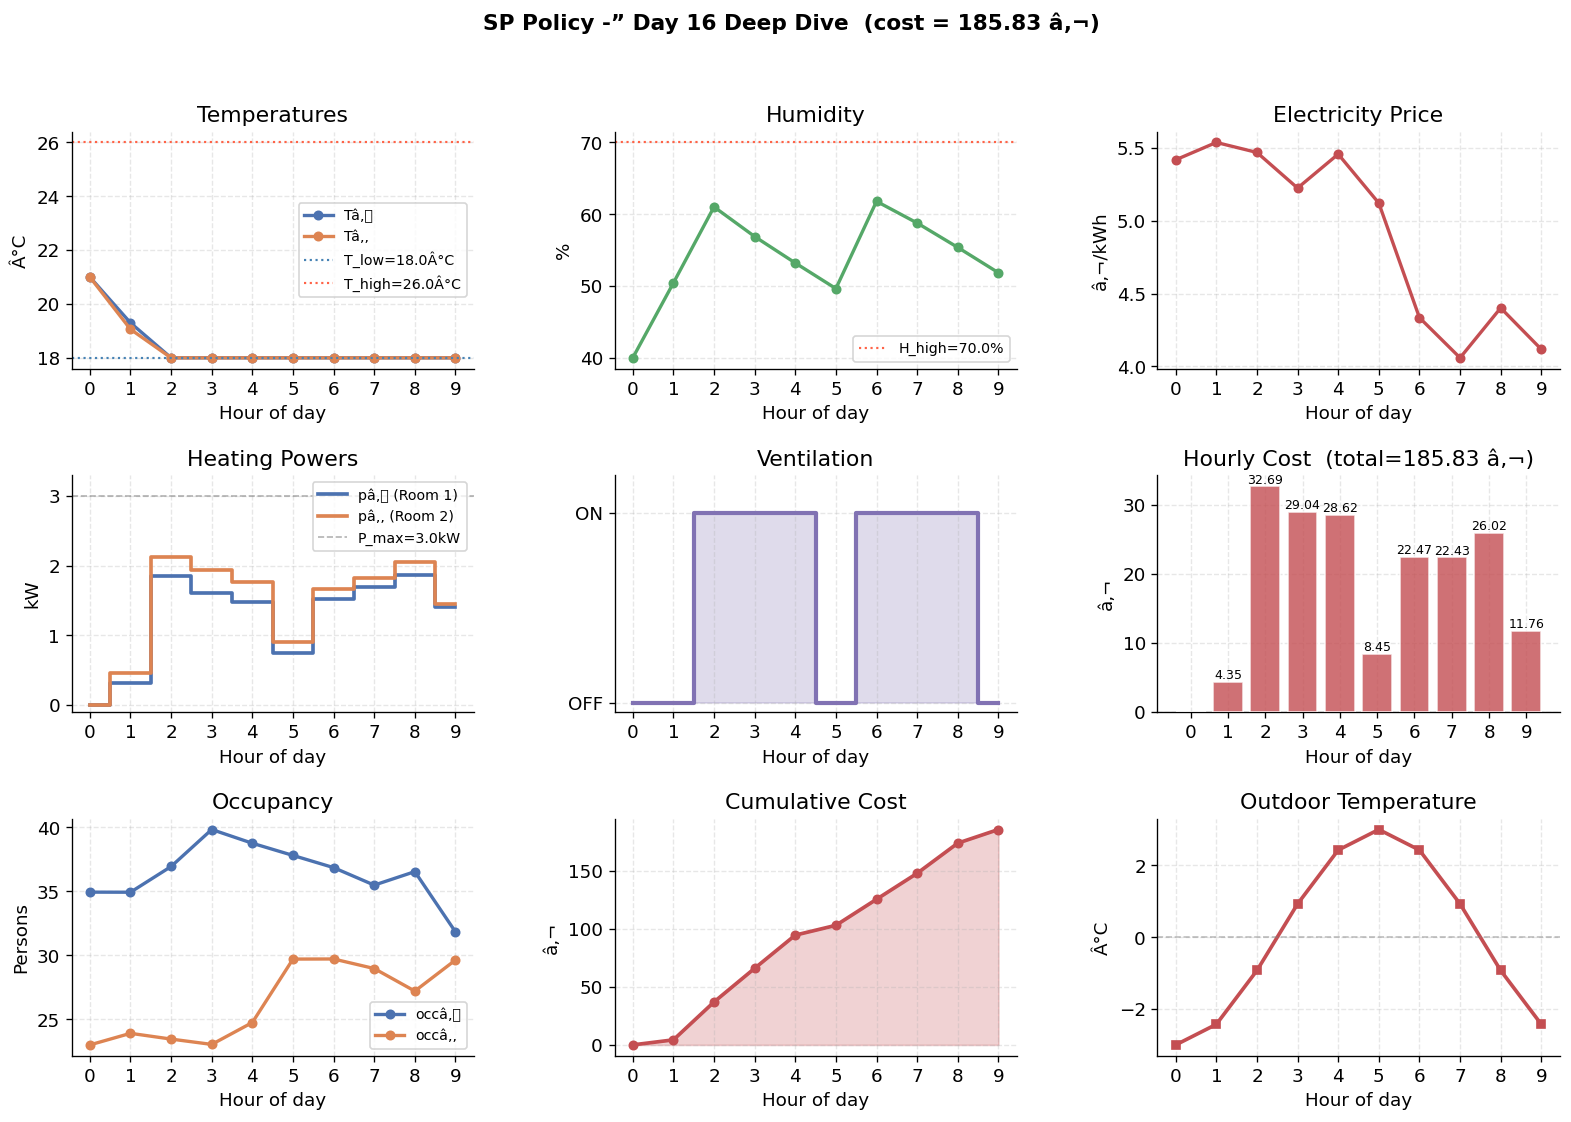

In [68]:
DAY = int(np.argmin(np.abs(R["daily_costs"] - np.median(R["daily_costs"]))))
print(f"Showing day {DAY+1}  |  daily cost = {R['daily_costs'][DAY]:.2f} â‚¬  (â‰ˆ median)")

fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

kw_line = dict(lw=2.0, marker="o", ms=5)

# Row 0 -” Temperatures
ax = fig.add_subplot(gs[0, 0])
ax.plot(HOURS, R["T1"][DAY], color="#4C72B0", **kw_line, label="Tâ‚")
ax.plot(HOURS, R["T2"][DAY], color="#DD8452", **kw_line, label="Tâ‚‚")
ax.axhline(SYS["T_low"],  color="steelblue", ls=":", lw=1.3, label=f'T_low={SYS["T_low"]}Â°C')
ax.axhline(SYS["T_high"], color="tomato",    ls=":", lw=1.3, label=f'T_high={SYS["T_high"]}Â°C')
ax.set_title("Temperatures"); ax.set_ylabel("Â°C"); ax.set_xticks(HOURS); ax.legend(fontsize=8.5)

# Row 0 -” Humidity
ax = fig.add_subplot(gs[0, 1])
ax.plot(HOURS, R["H"][DAY], color="#55A868", **kw_line)
ax.axhline(SYS["H_high"], color="tomato", ls=":", lw=1.3, label=f'H_high={SYS["H_high"]}%')
ax.set_title("Humidity"); ax.set_ylabel("%"); ax.set_xticks(HOURS); ax.legend(fontsize=8.5)

# Row 0 -” Price
ax = fig.add_subplot(gs[0, 2])
ax.plot(HOURS, R["prices"][DAY], color="#C44E52", **kw_line)
ax.set_title("Electricity Price"); ax.set_ylabel("â‚¬/kWh"); ax.set_xticks(HOURS)

# Row 1 -” Heating powers
ax = fig.add_subplot(gs[1, 0])
ax.step(HOURS, R["p1"][DAY], where="mid", color="#4C72B0", lw=2.2, label="pâ‚ (Room 1)")
ax.step(HOURS, R["p2"][DAY], where="mid", color="#DD8452", lw=2.2, label="pâ‚‚ (Room 2)")
ax.axhline(SYS["P_max"], color="gray", ls="--", lw=1, alpha=0.6, label=f'P_max={SYS["P_max"]}kW')
ax.set_ylim(-0.1, SYS["P_max"] + 0.3)
ax.set_title("Heating Powers"); ax.set_ylabel("kW"); ax.set_xticks(HOURS); ax.legend(fontsize=8.5)

# Row 1 -” Ventilation
ax = fig.add_subplot(gs[1, 1])
ax.step(HOURS, R["v"][DAY], where="mid", color="#8172B3", lw=2.5)
ax.fill_between(HOURS, 0, R["v"][DAY], step="mid", color="#8172B3", alpha=0.25)
ax.set_ylim(-0.05, 1.2); ax.set_yticks([0, 1]); ax.set_yticklabels(["OFF", "ON"])
ax.set_title("Ventilation"); ax.set_xticks(HOURS)

# Row 1 -” Hourly cost
ax = fig.add_subplot(gs[1, 2])
bars = ax.bar(HOURS, R["cost_log"][DAY], color="#C44E52", alpha=0.8, edgecolor="white", zorder=3)
ax.set_title(f"Hourly Cost  (total={R['daily_costs'][DAY]:.2f} â‚¬)")
ax.set_ylabel("â‚¬"); ax.set_xticks(HOURS)
for bar, v in zip(bars, R["cost_log"][DAY]):
    if v > 0.05:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)

# Row 2 -” Occupancies
ax = fig.add_subplot(gs[2, 0])
ax.plot(HOURS, R["occ1"][DAY], color="#4C72B0", **kw_line, label="occâ‚")
ax.plot(HOURS, R["occ2"][DAY], color="#DD8452", **kw_line, label="occâ‚‚")
ax.set_title("Occupancy"); ax.set_ylabel("Persons"); ax.set_xticks(HOURS); ax.legend(fontsize=8.5)

# Row 2 -” Cumulative cost
ax = fig.add_subplot(gs[2, 1])
cum_cost = np.cumsum(R["cost_log"][DAY])
ax.fill_between(HOURS, 0, cum_cost, color="#C44E52", alpha=0.25)
ax.plot(HOURS, cum_cost, color="#C44E52", lw=2.2, marker="o", ms=5)
ax.set_title("Cumulative Cost"); ax.set_ylabel("â‚¬"); ax.set_xticks(HOURS)

# Row 2 -” Outdoor temperature
ax = fig.add_subplot(gs[2, 2])
T_outdoor = np.array([T_out(t) for t in range(10)])
ax.plot(HOURS, T_outdoor, color="#C44E52", lw=2.2, marker="s", ms=5)
ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.5)
ax.set_title("Outdoor Temperature"); ax.set_ylabel("Â°C"); ax.set_xticks(HOURS)

# Common x-label
for ax in fig.axes:
    ax.set_xlabel("Hour of day")

fig.suptitle(f"SP Policy -” Day {DAY+1} Deep Dive  (cost = {R['daily_costs'][DAY]:.2f} â‚¬)",
             fontsize=13, fontweight="bold")
plt.show()

## 6. Summary Statistics

In [69]:
costs    = R["daily_costs"]
st_ms    = R["solve_times"] * 1000
ov       = R["overrule"]
N        = R["n_days"]
total_steps = N * 10

# -- Thermal comfort ------------------------------------------------------------
T1_all = R["T1"].flatten()
T2_all = R["T2"].flatten()
H_all  = R["H"].flatten()
v_all  = R["v"].flatten()

T1_viol_lo  = (T1_all < SYS["T_low"]).mean()  * 100
T2_viol_lo  = (T2_all < SYS["T_low"]).mean()  * 100
T1_viol_hi  = (T1_all > SYS["T_high"]).mean() * 100
T2_viol_hi  = (T2_all > SYS["T_high"]).mean() * 100
H_viol      = (H_all  > SYS["H_high"]).mean() * 100

rows = [
    # Cost
    ("Simulation days",                    f"{N}"),
    ("MILP solves total",                  f"{N*10}"),
    ("--- COST ------------------------------------", ""),
    ("Mean daily cost",                    f"{costs.mean():.3f} â‚¬"),
    ("Std daily cost",                     f"{costs.std():.3f} â‚¬"),
    ("Min daily cost",                     f"{costs.min():.3f} â‚¬"),
    ("Max daily cost",                     f"{costs.max():.3f} â‚¬"),
    ("Coefficient of variation",           f"{costs.std()/costs.mean()*100:.1f} %"),
    ("--- COMFORT ---------------------------------", ""),
    ("Tâ‚ below T_low  (18 Â°C)",            f"{T1_viol_lo:.2f} % of steps"),
    ("Tâ‚‚ below T_low  (18 Â°C)",            f"{T2_viol_lo:.2f} % of steps"),
    ("Tâ‚ above T_high (26 Â°C)",            f"{T1_viol_hi:.2f} % of steps"),
    ("Tâ‚‚ above T_high (26 Â°C)",            f"{T2_viol_hi:.2f} % of steps"),
    ("H above H_high  (70 %)",             f"{H_viol:.2f} % of steps"),
    ("--- ACTIONS ---------------------------------", ""),
    ("Mean heating pâ‚",                    f"{R['p1'].mean():.3f} kW"),
    ("Mean heating pâ‚‚",                    f"{R['p2'].mean():.3f} kW"),
    ("Ventilation ON rate",                f"{v_all.mean()*100:.1f} %"),
    ("--- OVERRULE CONTROLLERS --------------------", ""),
    ("Low-T override Room 1",              f"{ov['lo1']} times  ({ov['lo1']/total_steps*100:.2f} %)"),
    ("Low-T override Room 2",              f"{ov['lo2']} times  ({ov['lo2']/total_steps*100:.2f} %)"),
    ("High-T override Room 1",             f"{ov['hi1']} times  ({ov['hi1']/total_steps*100:.2f} %)"),
    ("High-T override Room 2",             f"{ov['hi2']} times  ({ov['hi2']/total_steps*100:.2f} %)"),
    ("Humidity override",                  f"{ov['hum']} times  ({ov['hum']/total_steps*100:.2f} %)"),
    ("--- COMPUTATION -----------------------------", ""),
    ("Mean solve time",                    f"{st_ms.mean():.1f} ms"),
    ("95th pct solve time",                f"{np.percentile(st_ms,95):.1f} ms"),
    ("Max solve time",                     f"{st_ms.max():.1f} ms"),
    ("Any timeout? (> 15 000 ms)",         "Yes" if st_ms.max() > 15000 else "No"),
]

df = pd.DataFrame(rows, columns=["Metric", "Value"])

# Style the separator rows
def highlight_sep(row):
    if row["Metric"].startswith("-"):
        return ["background-color: #e8eaf6; font-weight: bold"] * 2
    return [""] * 2

display(df.style.apply(highlight_sep, axis=1).hide(axis="index").set_table_styles([
    {"selector": "th", "props": [("background-color", "#3949AB"), ("color", "white"),
                                   ("font-size", "13px"), ("text-align", "left")]},
    {"selector": "td", "props": [("font-size", "12px"), ("padding", "5px 12px")]},
]))

Metric,Value
Simulation days,50
MILP solves total,500
--- COST ------------------------------------,
Mean daily cost,187.687 â‚¬
Std daily cost,72.992 â‚¬
Min daily cost,63.022 â‚¬
Max daily cost,318.130 â‚¬
Coefficient of variation,38.9 %
--- COMFORT ---------------------------------,
Tâ‚ below T_low (18 Â°C),0.20 % of steps
